<a href="https://colab.research.google.com/github/lakshmi220/GenAI_2026/blob/main/IMDB_Sentiment_Exercise_fin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis: From Bag-of-Words to Neural Classifiers

---

> ### 📋 Assignment
> You will build a complete sentiment classification pipeline on the **IMDB Movie Review** dataset — 50,000 reviews labelled positive or negative.
>
> **Part 1** uses classical machine learning on **binary one-hot vectors** — the simplest possible text representation.
> **Part 2** introduces neural sequence models for NLP. The boilerplate (data loading, vocabulary, training loop, evaluation) is **fully provided and pre-written**. Your job is to:
> 1. Build the **model architectures** (`### CODE HERE ###` inside `nn.Module` classes)
> 2. Write **interpretation and reflection** cells
>
> **Cells marked `# ── PROVIDED ──` carry no marks** — just run them.
> **Cells marked `### CODE HERE ###` carry marks** — these are yours to complete.
>
> Use `random_state=42` wherever accepted.

---

## What You Will Build

| Part | Approach | Key Idea |
|------|----------|----------|
| **Part 1** | Classical ML — LR, Naive Bayes, SVM, Random Forest | Binary one-hot vectors (word present/absent) |
| **Part 2A** | Vanilla RNN | Reads tokens sequentially; hidden state carries context |
| **Part 2B** | LSTM | Gated memory solves long-range forgetting |
| **Part 2C** | Bidirectional LSTM + FastText embeddings | Both-direction context + pre-trained word meaning |
| **Part 2D** | Cross-Attention Classifier | Every token attends to every other — no sequential bottleneck |

**Total Marks: 100** (Part 1: 45 | Part 2: 55)

### The Central Question
> *Can a model reading `"the film is not as bad as critics claimed"` correctly identify it as **positive**?*
>
> A one-hot vector sees `bad` and `critics` as present — and guesses *negative*. A neural model reading the full sentence in order has a fighting chance. An attention model can show you exactly which words it focused on.

---

# PART 1: Classical Sentiment Classification

## Context

The IMDB dataset contains 50,000 movie reviews — 25,000 for training, 25,000 for testing, perfectly balanced between positive and negative.

Reviews average **~230 words** — long enough that word order and negation genuinely matter. In this part, you will represent each review as a **binary one-hot vector**: a vector of 0s and 1s where a 1 simply means a word appeared in the review, and 0 means it did not. Frequency is ignored entirely — `"masterpiece"` appearing once and `"bad"` appearing ten times both become 1.

This is intentionally the simplest possible text representation. It sets a realistic ceiling that the neural models in Part 2 need to meaningfully exceed. You will see exactly where this representation breaks down.

## Stage 1: Data Loading  <font color="red">**[4 marks]**</font>

**What to do:**
- The libraries below are pre-imported. Add anything else you need.
- Load the IMDB dataset using `load_dataset('imdb')` from HuggingFace.
- Extract train texts, test texts, and their labels into plain Python lists.
- Print the number of examples and class distribution.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, confusion_matrix, classification_report)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

In [ ]:
# Load the IMDB dataset
import os
from google.colab import userdata
os.environ["HF_TOKEN"]= userdata.get('lk_hf_token')
dataset     = load_dataset("stanfordnlp/imdb")  ### CODE HERE ###
train_texts  = dataset['train']['text']  ### CODE HERE ###
train_labels = dataset['train']['label']
test_texts   = dataset['test']['text']### CODE HERE ###
test_labels  = dataset['train']['label']### CODE HERE ###
y_train = np.array(train_labels)
y_test  = np.array(test_labels)

# Sentiment Analysis: From Bag-of-Words to Neural Classifiers

---

> ### 📋 Assignment
> You will build a complete sentiment classification pipeline on the **IMDB Movie Review** dataset — 50,000 reviews labelled positive or negative.
>
> **Part 1** uses classical machine learning on **binary one-hot vectors** — the simplest possible text representation.
> **Part 2** introduces neural sequence models for NLP. The boilerplate (data loading, vocabulary, training loop, evaluation) is **fully provided and pre-written**. Your job is to:
> 1. Build the **model architectures** (`### CODE HERE ###` inside `nn.Module` classes)
> 2. Write **interpretation and reflection** cells
>
> **Cells marked `# ── PROVIDED ──` carry no marks** — just run them.
> **Cells marked `### CODE HERE ###` carry marks** — these are yours to complete.
>
> Use `random_state=42` wherever accepted.

---

## What You Will Build

| Part | Approach | Key Idea |
|------|----------|----------|
| **Part 1** | Classical ML — LR, Naive Bayes, SVM, Random Forest | Binary one-hot vectors (word present/absent) |
| **Part 2A** | Vanilla RNN | Reads tokens sequentially; hidden state carries context |
| **Part 2B** | LSTM | Gated memory solves long-range forgetting |
| **Part 2C** | Bidirectional LSTM + FastText embeddings | Both-direction context + pre-trained word meaning |
| **Part 2D** | Cross-Attention Classifier | Every token attends to every other — no sequential bottleneck |

**Total Marks: 100** (Part 1: 45 | Part 2: 55)

### The Central Question
> *Can a model reading `"the film is not as bad as critics claimed"` correctly identify it as **positive**?*
>
> A one-hot vector sees `bad` and `critics` as present — and guesses *negative*. A neural model reading the full sentence in order has a fighting chance. An attention model can show you exactly which words it focused on.

---

# PART 1: Classical Sentiment Classification

## Context

The IMDB dataset contains 50,000 movie reviews — 25,000 for training, 25,000 for testing, perfectly balanced between positive and negative.

Reviews average **~230 words** — long enough that word order and negation genuinely matter. In this part, you will represent each review as a **binary one-hot vector**: a vector of 0s and 1s where a 1 simply means a word appeared in the review, and 0 means it did not. Frequency is ignored entirely — `"masterpiece"` appearing once and `"bad"` appearing ten times both become 1.

This is intentionally the simplest possible text representation. It sets a realistic ceiling that the neural models in Part 2 need to meaningfully exceed. You will see exactly where this representation breaks down.

In [6]:
# Print number of examples and label distribution
### CODE HERE ###
from collections import Counter
print(f"------- TRAIN DATA --------")
print(f"Train data exampes count : {len(train_texts)}" )
train_labels_cnt = Counter(train_labels)
print(f"-ve reviews : {train_labels_cnt[0] }" )
print(f"+ve reviews : {train_labels_cnt[1]}" )

print(f"------- TEST DATA --------")
print(f"Train data exampes count : {len(test_texts)}" )
test_labels_cnt = Counter(test_labels)
print(f"-ve reviews : {test_labels_cnt[0] }" )
print(f"+ve reviews : {test_labels_cnt[1]}" )

------- TRAIN DATA --------
Train data exampes count : 25000
-ve reviews : 12500
+ve reviews : 12500
------- TEST DATA --------
Train data exampes count : 25000
-ve reviews : 12500
+ve reviews : 12500


## Stage 2: Data Understanding  <font color="red">**[8 marks]**</font>

### 2.1 Class Distribution  <font color="red">[1 mark]</font>

Plot a bar chart of positive vs negative counts in the training set.

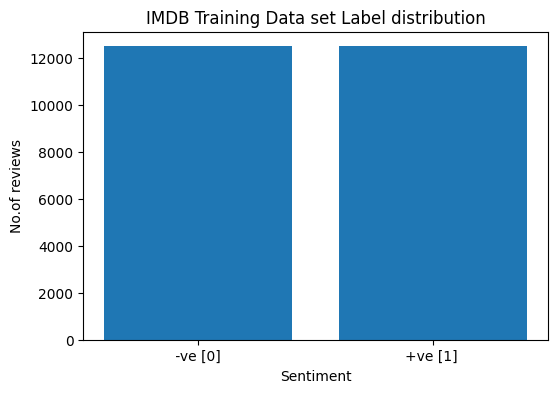

In [7]:
### CODE HERE ###
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar([" -ve [0] ","+ve [1] "],[train_labels_cnt[0],train_labels_cnt[1]])
plt.title("IMDB Training Data set Label distribution")
plt.xlabel("Sentiment")
plt.ylabel ("No.of reviews")
plt.show()

### 2.2 Review Length Distribution  <font color="red">[2 marks]</font>

Compute word count per training review. Plot a histogram and print the mean, median, and 95th percentile length.
Also plot lengths **separately for positive and negative reviews** using overlapping histograms.

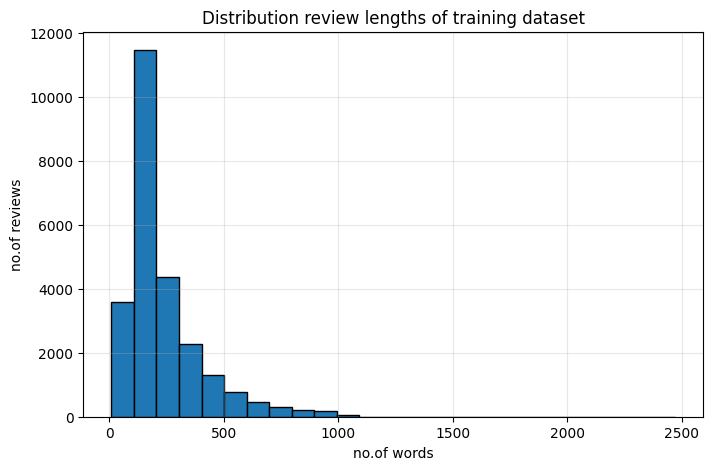

Mean    : 233.79 words
Median  : 174 words
95th percentile      : 598 words


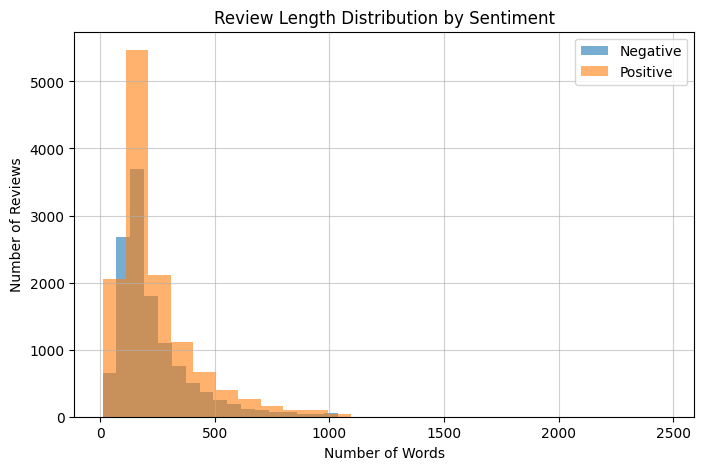

In [8]:
### CODE HERE ###
# Compute word counts
train_word_cnt = [ len(text.split()) for text in train_texts]


# Compute statistics
mean = np.mean(train_word_cnt)
median = np.median(train_word_cnt)
percentie_95 = np.percentile(train_word_cnt, 95)


# Histogram of all review lengths
plt.figure(figsize=(8,5))
plt.hist(train_word_cnt, bins=25, edgecolor="black")
plt.title("Distribution review lengths of training dataset")
plt.xlabel ("no.of words")
plt.ylabel("no.of reviews")
plt.grid(alpha=0.3)
plt.show()


print(f"Mean    : {mean:.2f} words")
print(f"Median  : {median:.0f} words")
print(f"95th percentile      : {percentie_95:.0f} words")


#seperate lengths by sentiment
positive_lengths = [
    len(text.split())
    for text,label in zip(train_texts,train_labels)
    if(label ==1)

]
negative_lengths = [
    len(text.split())
    for text,label in zip(train_texts,train_labels)
    if(label ==0)

]


# Overlapping histograms
plt.figure(figsize=(8,5))
plt.hist(negative_lengths, bins=25, alpha=0.6, label="Negative")
plt.hist(positive_lengths, bins=25, alpha=0.6, label="Positive")

plt.title("Review Length Distribution by Sentiment")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.legend()
plt.grid(alpha=0.6)
plt.show()



### 2.3 Sample Reviews  <font color="red">[1 mark]</font>

Print the first 200 characters of one positive and one negative review. Note any HTML artefacts you see.

In [9]:
### CODE HERE ###
import re
html_pattern  = re.compile(r"<[^>]+>")

positive_first_200_chars = next( text for text,lbl in zip(train_texts, train_labels) if(lbl==1) )[:200]
negative_first_200_chars = next( text for text,lbl in zip(train_texts, train_labels) if(lbl==0) )[:200]

if(html_pattern.search(positive_first_200_chars)) :
  print(" HTML tags found in one Positve review first 200 chars")
else:
  print("No HTML tags found one Positve review first 200 chars")
if(html_pattern.search(negative_first_200_chars)) :
  print(" HTML tags found in one Negative review first 200 chars")
else:
  print("No HTML tags found one Negative review first 200 chars")

print(f" positive_first_200_chars : {positive_first_200_chars}")
print(f" negative_first_200_chars : {negative_first_200_chars}")

No HTML tags found one Positve review first 200 chars
No HTML tags found one Negative review first 200 chars
 positive_first_200_chars : Zentropa has much in common with The Third Man, another noir-like film set among the rubble of postwar Europe. Like TTM, there is much inventive camera work. There is an innocent American who gets emo
 negative_first_200_chars : I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev


### 2.4 Top Words by Class  <font color="red">[2 marks]</font>

Fit a `CountVectorizer` (with `stop_words='english'`) on training data only.
Plot the top 20 most frequent words for positive reviews and negative reviews side by side.

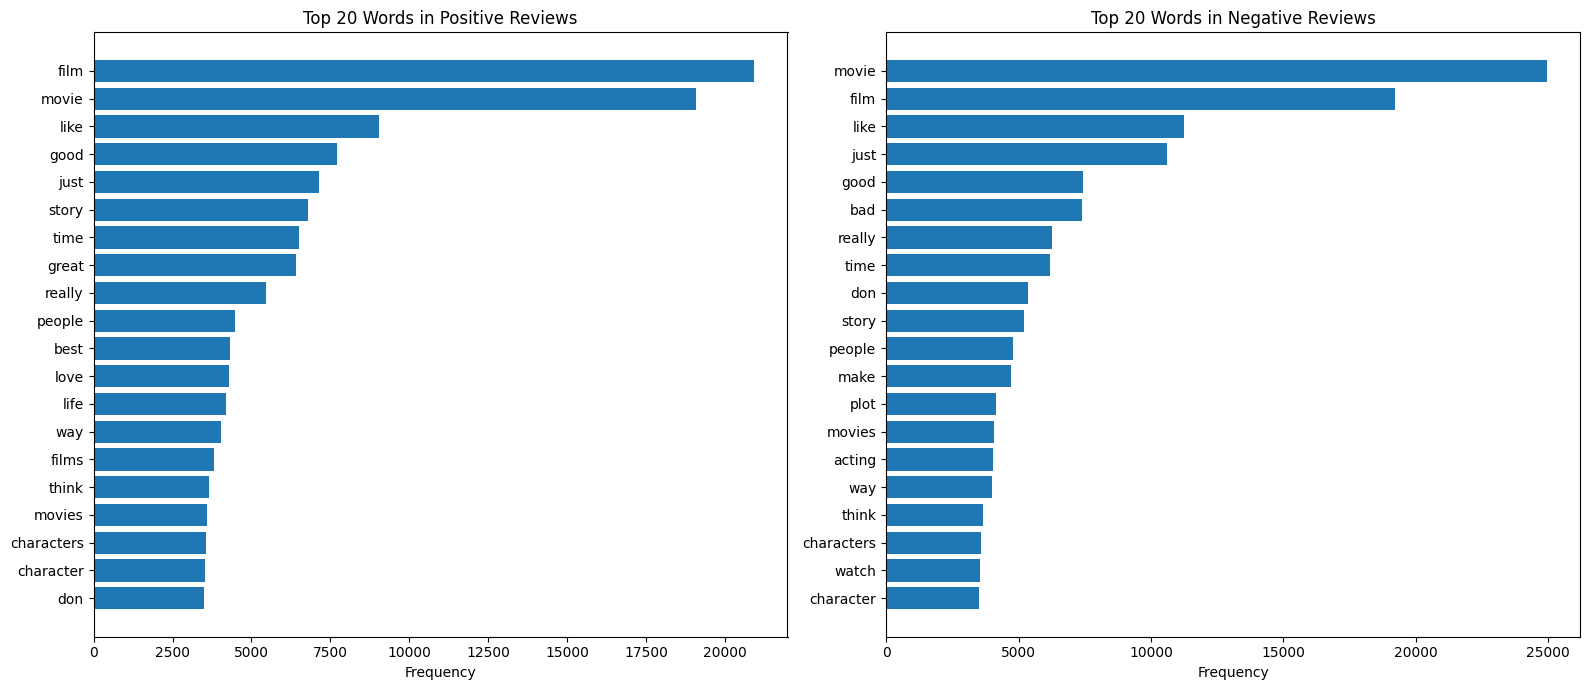

In [10]:
### CODE HERE ###
vectorizer = CountVectorizer(stop_words="english")

clean_train_text = [re.sub(r'<[^>]+>', '', item) for item in train_texts]

# Separate reviews
positive_reviews = [text for text, label in zip(train_texts, train_labels) if label == 1]
negative_reviews = [text for text, label in zip(train_texts, train_labels) if label == 0]

clean_positive_reviews = [re.sub(r'<[^>]+>', '', item) for item in positive_reviews]
clean_negative_reviews = [re.sub(r'<[^>]+>', '', item) for item in negative_reviews]



# Fit CountVectorizer on ALL training data only
vectorizer = CountVectorizer(stop_words="english")

vectorizer.fit(clean_train_text)

vocab = np.array(vectorizer.get_feature_names_out())

# Transform positive and negative reviews separately
X_pos = vectorizer.transform(clean_positive_reviews)
X_neg = vectorizer.transform(clean_negative_reviews)

# Sum word frequencies
pos_counts = np.asarray(X_pos.sum(axis=0)).flatten()
neg_counts = np.asarray(X_neg.sum(axis=0)).flatten()

# Top 20 words
top_pos_idx = np.argsort(pos_counts)[-20:]
top_neg_idx = np.argsort(neg_counts)[-20:]

top_pos_words = vocab[top_pos_idx]
top_pos_freq = pos_counts[top_pos_idx]


top_neg_words = vocab[top_neg_idx]
top_neg_freq = neg_counts[top_neg_idx]

# ----------------------------------------
# Plot side-by-side bar charts
# ----------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Positive
axes[0].barh(top_pos_words, top_pos_freq)
axes[0].set_title("Top 20 Words in Positive Reviews")
axes[0].set_xlabel("Frequency")

# Negative
axes[1].barh(top_neg_words, top_neg_freq)
axes[1].set_title("Top 20 Words in Negative Reviews")
axes[1].set_xlabel("Frequency")

plt.tight_layout()
plt.show()



### 2.5 Negation Examples  <font color="red">[2 marks]</font>

Find 5 training reviews where `"not"` appears at least 3 times. Print the first 50 words of each and their true label.

> These are the examples classical models will get wrong most often. Keep them in mind for Stage 6.

In [11]:
### CODE HERE ###
count = 0
for text, label in zip(clean_train_text, train_labels):
  # Count whole-word occurrences of "not" (case-insensitive)
  not_count = len(re.findall(r"\bnot\b", text.lower()))

  if(not_count>=3):
    first_50_words = " ".join(text.split()[:50])
    sentiment = "Positive" if label == 1 else "Negative"

    print("=" * 80)
    print(f"'not' count : {not_count}")
    print(f"True Label  : {sentiment} ({label})")
    print(f"Review      :\n{first_50_words}...")
    print()

    count += 1
  if count == 5:
      break

'not' count : 3
True Label  : Negative (0)
Review      :
When I first saw a glimpse of this movie, I quickly noticed the actress who was playing the role of Lucille Ball. Rachel York's portrayal of Lucy is absolutely awful. Lucille Ball was an astounding comedian with incredible talent. To think about a legend like Lucille Ball being portrayed the...

'not' count : 4
True Label  : Negative (0)
Review      :
Its not the cast. A finer group of actors, you could not find. Its not the setting. The director is in love with New York City, and by the end of the film, so are we all! Woody Allen could not improve upon what Bogdonovich has done here. If you...

'not' count : 3
True Label  : Negative (0)
Review      :
Today I found "They All Laughed" on VHS on sale in a rental. It was a really old and very used VHS, I had no information about this movie, but I liked the references listed on its cover: the names of Peter Bogdanovich, Audrey Hepburn, John Ritter and specially Dorothy...

'not' coun

### ✍️ Interpretation Checkpoint

**[Your Answer]:** Answer each question in 2–3 sentences.

1. Is the dataset balanced? Does this affect our choice of F1 vs accuracy?
2. The top words for positive and negative look nearly identical. Given that one-hot vectors give all words equal weight, why does this make sentiment classification especially hard?
3. Why is review length a specific problem for vanilla RNNs? (Think about what happens to gradients after 200+ backpropagation steps.)
4. Why should you remove `<br />` HTML tags before both one-hot vectorisation and neural models?

*Write your answers here:*

1. ***Yes, Datset is balanced. as the dataset is balanced, Accuracy is reliable primary metric, with F1 providing additional information  ***

2. ***Yes, one-hot encoding makes sentiment analysis hard, because it give equal weights to 'movie', 'character', 'excellent', 'good','bad', 'not' , 'terrible', 'boring' words. As a result, the feature vectors for positive and negative reviews become very similar, making it difficult for the classifier to distinguish between the two classes ***

3. *** most movie reviews are 200-300 long. some exceed 600 words long. A vanilla RNN processes one word at a time, during training error must be backpropogated through hundreds of time stamps. as a result gradients may become extreemly large or small and tends to forget the information from the beginning of the review. ***

4. ***<br/> and other html artefacts should removed as they add no value in understanding the reiew. ***

## Stage 3: Preprocessing and Feature Engineering  <font color="red">**[6 marks]**</font>

## Binary One-Hot Vectors: The Simplest Text Representation

A **binary one-hot vector** represents a document as a fixed-length vector of 0s and 1s:

- **1** = this word appeared at least once in the review
- **0** = this word did not appear

For a vocabulary of 50,000 words, each review becomes a vector of 50,000 numbers, almost all of which are 0.

```python
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(binary=True, max_features=50000)
# binary=True → all non-zero counts become 1
# Each row: 1 if word present, 0 if absent — frequency ignored
```

**What one-hot cannot represent:**
- **Frequency** — `"bad"` appearing 10 times looks identical to `"bad"` appearing once
- **Rarity** — `"masterpiece"` (rare, diagnostic) has the same weight as `"film"` (common, uninformative)
- **Order** — `"not bad"` and `"bad not"` produce identical vectors

This is a deliberately weak representation. The classical models in Stage 4 will plateau around **80–84% F1** — well below what TF-IDF would give — leaving clear room for neural models to improve.

**Critical rule:** Fit the vectoriser on **training data only**. Fitting on test data leaks vocabulary statistics into training.

### 3.1 Text Cleaning  <font color="red">[2 marks]</font>

Write a `clean_text(text)` function that:
- Removes HTML tags (`<br />`, `<b>`, etc.) using a regex
- Lowercases the text
- Strips leading/trailing whitespace

Apply it to all train and test texts. Print a before/after example to confirm it works.

In [12]:
def clean_text(text):
    ### CODE HERE ###
   clean_train_text = [re.sub(r'<[^>]+>', '', review) for review in text]
   return clean_train_text

# Apply to train and test
### CODE HERE ###
clean_train_text = clean_text(train_texts)
clean_test_text = clean_text(test_texts)

# Print one before/after example
### CODE HERE ###
print (f"Before HTML cleaning : {train_texts[0][:500]}")

print (f"After HTML cleaning : {clean_train_text[0][:500]}")

Before HTML cleaning : I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attent
After HTML cleaning : I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In partic

### 3.2 Build One-Hot Features  <font color="red">[4 marks]</font>

Create a `CountVectorizer` with:
- `binary=True` — converts all counts to 0/1
- `max_features=50000` — keep the 50,000 most frequent words
- `min_df=5` — ignore words appearing in fewer than 5 reviews
- `stop_words='english'`

**Fit on training data only**, then transform both splits. Print the shape and sparsity of the resulting matrices.

> **Note:** No `ngram_range=(1,2)` this time — with one-hot, bigrams would double the already-large feature space with minimal benefit. Unigrams only.

In [13]:
### CODE HERE ###
# Create CountVectorizer
vectorizer = CountVectorizer(
    binary=True,
    max_features=50000,
    min_df=5,
    stop_words="english"
)

X_train = clean_train_text
y_train = train_labels

X_test = clean_test_text
y_test = test_labels

# Fit ONLY on training data
X_train_vec = vectorizer.fit_transform(X_train)

# Transform test data
X_test_vec = vectorizer.transform(X_test)

# Print shapes
print("Training matrix shape :", X_train_vec.shape)
print("Test matrix shape     :", X_test_vec.shape)

# Compute sparsity
train_sparsity = 100 * (
    1 - X_train_vec.nnz / (X_train_vec.shape[0] * X_train_vec.shape[1])
)

test_sparsity = 100 * (
    1 - X_test_vec.nnz / (X_test_vec.shape[0] * X_test_vec.shape[1])
)

print(f"Training sparsity : {train_sparsity:.2f}%")
print(f"Test sparsity     : {test_sparsity:.2f}%")

Training matrix shape : (25000, 26958)
Test matrix shape     : (25000, 26958)
Training sparsity : 99.68%
Test sparsity     : 99.69%


## Helper: Evaluation Function

Define a reusable `evaluate_model(name, y_true, y_pred)` function. It should:
- Print accuracy, F1, precision, recall
- Print a `classification_report`
- Plot a confusion matrix heatmap
- Return the metrics as a dict (for building a comparison table later)

In [14]:
def evaluate_model(name, y_true, y_pred):
    ### CODE HERE ###
     # Compute metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    # Print metrics
    print("=" * 60)
    print(f"Model: {name}")
    print("=" * 60)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    # Classification report
    print("\nClassification Report")
    print("-" * 60)
    print(classification_report(
        y_true,
        y_pred,
        target_names=["Negative", "Positive"]
    ))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"]
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

    # Return metrics for comparison later
    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

## Using Pipeline + GridSearchCV for Text

Chain the vectoriser and classifier in a `Pipeline`, then wrap in `GridSearchCV`. This ensures the vectoriser is re-fit on each cross-validation fold — preventing data leakage.

```python
pipe = Pipeline([
    ('vec', CountVectorizer(binary=True, min_df=5, stop_words='english')),
    ('clf', LogisticRegression(random_state=42))
])
param_grid = {
    'vec__max_features': [20000, 50000],   # prefix is the pipeline step name
    'clf__C':            [0.1, 1, 10]
}
grid = GridSearchCV(pipe, param_grid, scoring='f1', cv=5, n_jobs=-1)
grid.fit(train_texts_clean, y_train)   # pass CLEANED TEXT — not the matrix
```

> **Important:** Pass cleaned raw text to `grid.fit()`. The pipeline applies the vectoriser internally at each fold, which is what prevents leakage.

## Stage 4: Model Training, Tuning, and Evaluation  <font color="red">**[20 marks]**</font>

Train **four classifiers**. For each: build a Pipeline with a `CountVectorizer(binary=True, ...)`, run GridSearchCV with `scoring='f1'` and `cv=5`, print best params and CV score, then evaluate on the test set using `evaluate_model()`.

> **Expected F1 range:** ~78–84%. One-hot vectors give no frequency or rarity information, so classical models cannot achieve the same ceiling as TF-IDF. This is deliberate — it leaves meaningful room for neural models to improve.

### 4.1 Logistic Regression  <font color="red">[5 marks]</font>

Hyperparameters to tune:
- `vec__max_features`: `[20000, 50000]`
- `clf__C`: `[0.01, 0.1, 1, 10]`

Set `max_iter=1000`, `random_state=42`.

In [15]:
def predictAndEvaluateModel(model_name,classifier, param_grid):

    # Pipeline
    pipe = Pipeline([
        (
            "vec",
            CountVectorizer(
                binary=True,
                min_df=5,
                stop_words="english"
            )
        ),
        ("clf", classifier)
    ])

    # Grid Search
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring="f1",
        cv=5,
        n_jobs=-1
    )

    # Train
    grid.fit(list(X_train), list(y_train))

    print("Best Parameters:")
    print(grid.best_params_)

    print(f"Best CV F1 Score: {grid.best_score_:.4f}")

    # Test predictions
    y_pred = grid.predict(X_test)

    # Evaluate
    metrics = evaluate_model(
        model_name,
        y_test,
        y_pred
    )

    metrics["Best Params"] = grid.best_params_
    metrics[model_name] = grid
    return  metrics





In [16]:
results = []

Best Parameters:
{'clf__C': 0.01, 'vec__max_features': 20000}
Best CV F1 Score: 0.8663
Model: Logistic Regression
Accuracy : 0.8733
Precision: 0.8656
Recall   : 0.8838
F1 Score : 0.8746

Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

    Negative       0.88      0.86      0.87     12500
    Positive       0.87      0.88      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



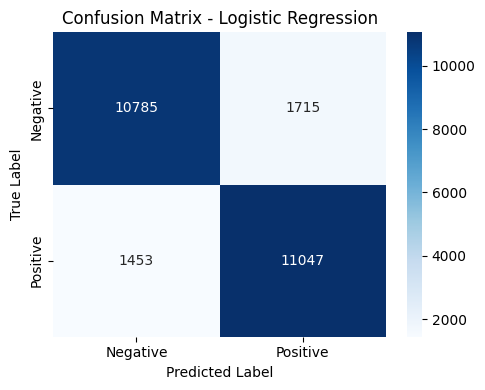

In [17]:
# Predict on test set and evaluate
### CODE HERE ###
lr = LogisticRegression(random_state=42, max_iter=1000)
param_grid=       {
            "vec__max_features": [20000, 50000],
            "clf__C": [0.01, 0.1, 1, 10]
        }

lr_metrics = predictAndEvaluateModel("Logistic Regression", lr, param_grid )
results.append(lr_metrics)

### 4.2 Bernoulli Naive Bayes  <font color="red">[5 marks]</font>

Use `BernoulliNB` — the variant of Naive Bayes designed specifically for **binary features**. It models each word as a Bernoulli (present/absent) trial, which matches our one-hot representation exactly.

Hyperparameters to tune:
- `vec__max_features`: `[20000, 50000]`
- `clf__alpha`: `[0.01, 0.1, 0.5, 1.0]`

> **Why BernoulliNB and not ComplementNB?** `ComplementNB` is designed for count features. `BernoulliNB` is the correct choice for binary presence/absence data — it penalises words that are *absent* from a class, which is meaningful when features are truly binary.

Best Parameters:
{'clf__alpha': 1.0, 'vec__max_features': 20000}
Best CV F1 Score: 0.7982
Model: Bernoulli Naive
Accuracy : 0.8232
Precision: 0.8685
Recall   : 0.7617
F1 Score : 0.8116

Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

    Negative       0.79      0.88      0.83     12500
    Positive       0.87      0.76      0.81     12500

    accuracy                           0.82     25000
   macro avg       0.83      0.82      0.82     25000
weighted avg       0.83      0.82      0.82     25000



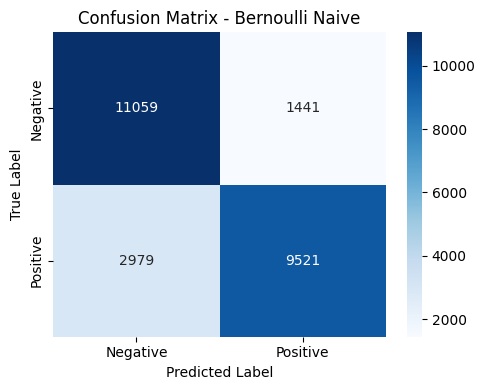

In [18]:
### CODE HERE ###
# written code to predict and evaluate  with clf__alpha : [0.01, 0.1, 0.5, 1.0]

ber_naive = BernoulliNB()
bn_param_grid={
            "vec__max_features": [20000, 50000],
            "clf__alpha": [0.01, 0.1, 0.5, 1.0]
           }

bn_metrics = predictAndEvaluateModel("Bernoulli Naive", ber_naive, bn_param_grid )
results.append(bn_metrics)

### 4.3 LinearSVC  <font color="red">[5 marks]</font>

Hyperparameters to tune:
- `vec__max_features`: `[20000, 50000]`
- `clf__C`: `[0.01, 0.1, 1, 10]`

Set `random_state=42`, `max_iter=2000`.

Best Parameters:
{'clf__C': 0.01, 'vec__max_features': 50000}
Best CV F1 Score: 0.8620
Model: Linear SVC
Accuracy : 0.8741
Precision: 0.8714
Recall   : 0.8777
F1 Score : 0.8745

Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

    Negative       0.88      0.87      0.87     12500
    Positive       0.87      0.88      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



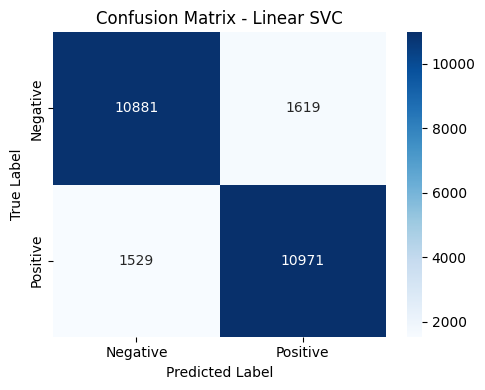

In [19]:
### CODE HERE ###
# written code to predict and evaluate  with clf__C: [0.01, 0.1, 1, 10] and random_state=42, max_iter=2000

lin_svc = LinearSVC(random_state=42, max_iter=2000)
ls_param_grid={
            "vec__max_features": [20000, 50000],
            "clf__C": [0.01, 0.1, 1, 10]
           }

ls_metrics = predictAndEvaluateModel("Linear SVC", lin_svc, ls_param_grid )
results.append(ls_metrics)

In [20]:
results


[{'Model': 'Logistic Regression',
  'Accuracy': 0.87328,
  'Precision': 0.8656166745024291,
  'Recall': 0.88376,
  'F1 Score': 0.8745942522365608,
  'Best Params': {'clf__C': 0.01, 'vec__max_features': 20000},
  'Logistic Regression': GridSearchCV(cv=5,
               estimator=Pipeline(steps=[('vec',
                                          CountVectorizer(binary=True, min_df=5,
                                                          stop_words='english')),
                                         ('clf',
                                          LogisticRegression(max_iter=1000,
                                                             random_state=42))]),
               n_jobs=-1,
               param_grid={'clf__C': [0.01, 0.1, 1, 10],
                           'vec__max_features': [20000, 50000]},
               scoring='f1')},
 {'Model': 'Bernoulli Naive',
  'Accuracy': 0.8232,
  'Precision': 0.8685458857872651,
  'Recall': 0.76168,
  'F1 Score': 0.8116102634046544,
  'Bes

### 4.4 Random Forest  <font color="red">[5 marks]</font>

Random Forest builds many decision trees on random subsets of features and takes a majority vote. It handles high-dimensional sparse binary vectors well and naturally produces **feature importances** — making it ideal for Stage 5.3.

Hyperparameters to tune:
- `vec__max_features`: `[20000, 50000]`
- `clf__n_estimators`: `[100, 200]`
- `clf__max_depth`: `[None, 20, 50]`
- `clf__min_samples_leaf`: `[1, 2]`

Set `random_state=42`, `n_jobs=-1`.

> **Note:** Random Forest is slower than LR or SVM on this dataset — expect ~2–3 minutes. This is normal.

Best Parameters:
{'clf__max_depth': None, 'clf__min_samples_leaf': 2, 'clf__n_estimators': 200, 'vec__max_features': 50000}
Best CV F1 Score: 0.8507
Model: RandomForest Classifier
Accuracy : 0.8549
Precision: 0.8541
Recall   : 0.8560
F1 Score : 0.8550

Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

    Negative       0.86      0.85      0.85     12500
    Positive       0.85      0.86      0.86     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



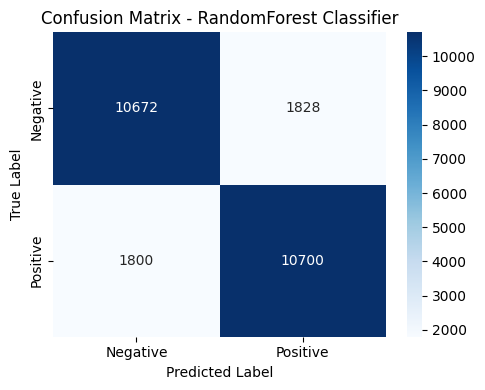

In [21]:
### CODE HERE ###
# written code  for Random Forest to predict and evaluate  with the above hyper parameters and random_state=42, n_jobs=-1
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_param_grid={
            "vec__max_features": [20000, 50000],
            "clf__n_estimators": [100, 200],
            "clf__max_depth": [None, 20, 50],
            "clf__min_samples_leaf": [1,2]
           }

rf_metrics = predictAndEvaluateModel("RandomForest Classifier", rf, rf_param_grid )
results.append(rf_metrics)

In [22]:
results

[{'Model': 'Logistic Regression',
  'Accuracy': 0.87328,
  'Precision': 0.8656166745024291,
  'Recall': 0.88376,
  'F1 Score': 0.8745942522365608,
  'Best Params': {'clf__C': 0.01, 'vec__max_features': 20000},
  'Logistic Regression': GridSearchCV(cv=5,
               estimator=Pipeline(steps=[('vec',
                                          CountVectorizer(binary=True, min_df=5,
                                                          stop_words='english')),
                                         ('clf',
                                          LogisticRegression(max_iter=1000,
                                                             random_state=42))]),
               n_jobs=-1,
               param_grid={'clf__C': [0.01, 0.1, 1, 10],
                           'vec__max_features': [20000, 50000]},
               scoring='f1')},
 {'Model': 'Bernoulli Naive',
  'Accuracy': 0.8232,
  'Precision': 0.8685458857872651,
  'Recall': 0.76168,
  'F1 Score': 0.8116102634046544,
  'Bes

## Stage 5: Classical Model Comparison  <font color="red">**[7 marks]**</font>

### 5.1 Comparison Table  <font color="red">[2 marks]</font>

Build a DataFrame comparing all four models on Accuracy, Precision, Recall, and F1. Sort by F1 descending.

In [23]:
### CODE HERE ###

comparison = pd.DataFrame(results)

comparison = comparison.sort_values(
    by="F1 Score",
    ascending=False
)
# Display only required columns
comparison = comparison[
    ["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
]
comparison


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.87328,0.865617,0.88376,0.874594
2,Linear SVC,0.87408,0.871406,0.87768,0.874532
3,RandomForest Classifier,0.85488,0.854087,0.85600,0.855042
1,Bernoulli Naive,0.82320,0.868546,0.76168,0.811610


### 5.2 Visualise  <font color="red">[2 marks]</font>

Grouped bar chart comparing Precision, Recall, and F1 across all four models.

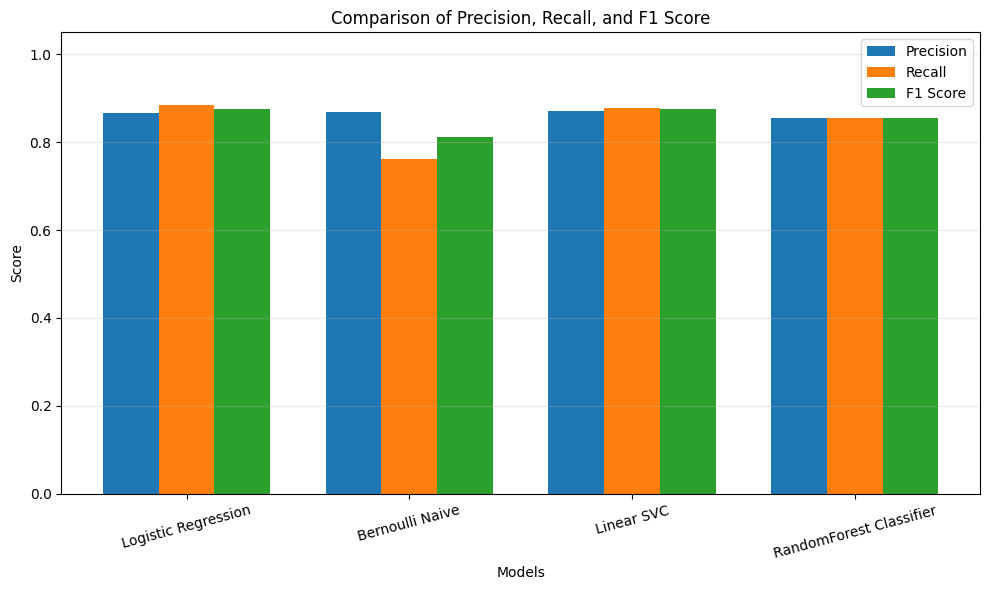

In [24]:
### CODE HERE ###

comparison_df = pd.DataFrame(results)

# Metrics to compare
metrics = ["Precision", "Recall", "F1 Score"]

# X-axis locations
x = np.arange(len(comparison_df))
width = 0.25

plt.figure(figsize=(10, 6))

# Plot grouped bars
for i, metric in enumerate(metrics):
    plt.bar(
        x + i * width,
        comparison_df[metric],
        width=width,
        label=metric
    )

# Formatting
plt.xticks(
    x + width,
    comparison_df["Model"],
    rotation=15
)

plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Comparison of Precision, Recall, and F1 Score")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


### 5.3 Most Important Features  <font color="red">[3 marks]</font>

From the **Random Forest** pipeline, extract the top 20 most important words using `.feature_importances_`.

Plot them as a horizontal bar chart sorted by importance.

> **Note:** Random Forest importance is non-negative (unlike LR/SVM coefficients) — you cannot separate positive/negative direction. Instead, these are the words that most reduced impurity across all trees, regardless of direction. The most important words should be strong sentiment markers.

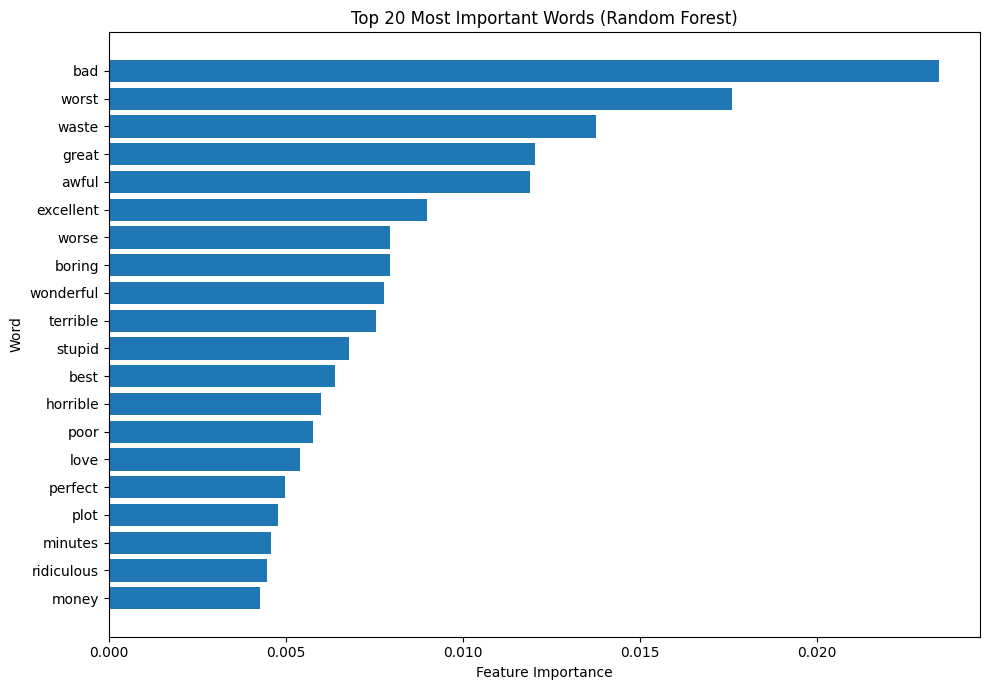

             Word  Importance
15642       money    0.004287
20208  ridiculous    0.004467
15434     minutes    0.004581
18024        plot    0.004784
17593     perfect    0.004977
14341        love    0.005406
18165        poor    0.005766
11631    horrible    0.005994
2438         best    0.006387
23194      stupid    0.006793
24042    terrible    0.007557
26600   wonderful    0.007786
2918       boring    0.007943
26659       worse    0.007958
8489    excellent    0.009001
1864        awful    0.011898
10532       great    0.012057
26149       waste    0.013772
26667       worst    0.017601
1937          bad    0.023447


In [25]:
#As I have saved Random Forest grid in results, just not to rerun it again here

# Find the Random Forest result
rf_result = next(r for r in results if r["Model"] == "RandomForest Classifier")

# Extract GridSearchCV object
rf_grid = rf_result["RandomForest Classifier"]

# Best pipeline
best_pipeline = rf_grid.best_estimator_

# Extract vectorizer and classifier
vectorizer = best_pipeline.named_steps["vec"]
rf_model = best_pipeline.named_steps["clf"]

# Feature names and importances
feature_names = vectorizer.get_feature_names_out()
importances = rf_model.feature_importances_

# Create DataFrame
importance_df = pd.DataFrame({
    "Word": feature_names,
    "Importance": importances
})

# Top 20 most important words
top20 = (
    importance_df
    .sort_values("Importance", ascending=False)
    .head(20)
    .sort_values("Importance")      # for horizontal bar chart
)

# Plot
plt.figure(figsize=(10, 7))
plt.barh(top20["Word"], top20["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Word")
plt.title("Top 20 Most Important Words (Random Forest)")
plt.tight_layout()
plt.show()

# Optional: print table
print(top20)


## Stage 6: Part 1 Reflection  <font color="red">**[8 marks]**</font>

**[Your Answer]:** Answer each question. Cite specific numbers from your results.

1. What is the F1 ceiling for classical models using one-hot vectors? How does this compare to what TF-IDF typically achieves (~87–89%)? What specific information does TF-IDF have that one-hot vectors lack?
2. Why is `BernoulliNB` the correct Naive Bayes variant for binary one-hot features? What would happen if you used `MultinomialNB` instead?
3. Find **3 reviews your best model got wrong**. Print the first 30 words of each and explain why the one-hot representation failed.
4. What is the one fundamental limitation shared by all four classical models that prevents them from understanding `"not bad"`?

*Write your answers here:*

1. **The practical F1 ceiling is approximately:≈ 0.87 (87%) . simply changing the classifier rarely improves performance because the feature representation becomes the limiting factor. TF-IDF usually achieves: ≈ 0.87–0.89 F1. This is often 1–3 percentage points better than binary one-hot vectors. A one-hot vector only records whether a word appears. where as TF-IDF records how often a word appears , how rare or informative  the word is**

2. **BernoulliNB is designed for binary features. vectorizer uses binary=True. matters only present/absent . BernoulliNB models exactly this.MultinomialNB assumes each feature represents a word count. Therefore MultinomialNB receives data that violate its assumptions.It still works, but BernoulliNB is statistically the correct model for binary one-hot features.**

3. **printed misclaasified review below. one-hot can't understand 'isn't bad', 'haven't enjoyed' words as bad. it treats 'enjoyed' as good and 'bad'  as negative.**

4. ***All four models share exactly the same input representation- 'bag of independent words' They ignore:word order,grammar,syntax,context. they treat 'not bad' as 'not' , 'bad'***

In [26]:
# Find and print 3 misclassified reviews from your best model


### CODE HERE ###

#for me, Logistic REgression turned out as best model with F1-0.8745
# Find the Random Forest result
lr_result = next(r for r in results if r["Model"] == "Logistic Regression")

# Extract GridSearchCV object
lr_grid = lr_result["Logistic Regression"]
# Best Random Forest pipeline
best_lr = lr_grid.best_estimator_

# Predictions
y_pred = best_lr.predict(clean_test_text)

misclassified = []

for text, true, pred in zip(clean_test_text, y_test, y_pred):
    if true != pred:
        misclassified.append((text, true, pred))

for i, (text, true, pred) in enumerate(misclassified[:3], start=1):
    print(f"\nReview {i}")
    print("-" * 60)
    print("True:", "Positive" if true else "Negative")
    print("Pred:", "Positive" if pred else "Negative")
    print("Text:")
    print(" ".join(text.split()[:30]))


Review 1
------------------------------------------------------------
True: Negative
Pred: Positive
Text:
Worth the entertainment value of a rental, especially if you like action movies. This one features the usual car chases, fights with the great Van Damme kick style, shooting battles

Review 2
------------------------------------------------------------
True: Negative
Pred: Positive
Text:
First off let me say, If you haven't enjoyed a Van Damme movie since bloodsport, you probably will not like this movie. Most of these movies may not have the

Review 3
------------------------------------------------------------
True: Negative
Pred: Positive
Text:
Blind Date (Columbia Pictures, 1934), was a decent film, but I have a few issues with this film. First of all, I don't fault the actors in this film at


---
# PART 2: Neural Sentiment Classifiers

## Context

Classical models with one-hot vectors have three fundamental weaknesses:
1. **No frequency** — `"bad"` appearing once = `"bad"` appearing ten times
2. **No rarity signal** — `"film"` (meaningless) has the same weight as `"masterpiece"` (highly diagnostic)
3. **No word order** — `"not bad"` and `"bad not"` are identical vectors

Neural sequence models address all three. They learn dense word representations (embeddings) that encode meaning, and process tokens sequentially or with attention to capture context.

## Your role in Part 2

All the boilerplate is written for you:
- Data pipeline (tokeniser, vocabulary, dataset class, dataloader)
- Training loop
- Evaluation function
- Positional encoding and attention mask utilities
- FastText embedding loader
- Attention visualisation

**You only write the model architectures and the interpretation cells.**

Read each concept box before building each model — they explain the new idea the architecture introduces.

## New NLP Concepts for Part 2

You know neural networks. Here is what is new when applying them to text:

### 1. Tokenisation and vocabulary
Instead of TF-IDF vectors, we convert each review to a **sequence of integer IDs**:
```
"not bad"  →  tokenise  →  ['not', 'bad']  →  map to IDs  →  [45, 312]
```
A **vocabulary** maps every known training word to a unique integer. Unknown words → `<UNK>` (ID 1). The padding token `<PAD>` (ID 0) is used to fill short sequences.

### 2. Padding and truncation
All sequences in a batch must be the same length. We fix every review to `MAX_LEN = 400`:
- Reviews longer than 400 tokens → keep the first 400 (truncate)
- Reviews shorter than 400 tokens → append zeros on the right (pad)

### 3. Embedding layer
`nn.Embedding(vocab_size, dim)` is a learnable lookup table. Row $i$ is the vector for word ID $i$. Unlike TF-IDF (sparse, one feature per word), embeddings are **dense** (e.g. 100 floats per word) and **learned from data**.
```python
self.embedding = nn.Embedding(vocab_size, 128, padding_idx=0)
# padding_idx=0 → PAD tokens get a zero vector and don't affect gradients
```

### 4. Binary classification output
The model outputs **one logit per review** (not two — this is binary). Loss is `BCEWithLogitsLoss`.
Prediction: `sigmoid(logit) > 0.5` → class 1 (positive), else class 0 (negative).

## Stage 1: Setup  *(provided — run all cells, no marks)*

All cells in this stage are fully written. Run them in order, read the comments, and make sure you understand what each part does before moving to Stage 2A.

In [27]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__}  |  device: {device}')
if device.type == 'cpu':
    print('Tip: enable a GPU runtime in Google Colab (Runtime → Change runtime type → T4 GPU)')

torch.manual_seed(42)
np.random.seed(42)

PyTorch 2.11.0+cu128  |  device: cuda


In [28]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
# TOKENISER: strips HTML, lowercases, removes punctuation, splits on spaces.
def tokenize(text):
    text = re.sub(r'<[^>]+>', ' ', text)
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return text.split()

# VOCABULARY: built from training data only.
# Words appearing fewer than MIN_FREQ times are treated as unknown (<UNK>).
MIN_FREQ = 5
counter  = Counter()
for doc in train_texts:
    counter.update(tokenize(doc))

word2idx = {'<PAD>': 0, '<UNK>': 1}
for word, freq in counter.items():
    if freq >= MIN_FREQ:
        word2idx[word] = len(word2idx)

idx2word   = {v: k for k, v in word2idx.items()}
VOCAB_SIZE = len(word2idx)
print(f'Vocabulary: {VOCAB_SIZE:,} words  (words seen < {MIN_FREQ}× → <UNK>)')

Vocabulary: 29,123 words  (words seen < 5× → <UNK>)


In [29]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
# DATASET: converts a raw review + label into a fixed-length integer tensor.
MAX_LEN    = 400   # reviews longer than this are truncated; shorter ones are padded
BATCH_SIZE = 64

class IMDBDataset(Dataset):
    def __init__(self, texts, labels, word2idx, max_len):
        self.labels = labels
        self.seqs   = []
        for doc in texts:
            ids  = [word2idx.get(t, 1) for t in tokenize(doc)]  # unknown → 1
            ids  = ids[:max_len]                                  # truncate
            ids += [0] * (max_len - len(ids))                    # pad with 0
            self.seqs.append(ids)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (torch.tensor(self.seqs[idx],   dtype=torch.long),
                torch.tensor(self.labels[idx], dtype=torch.float))

train_ds = IMDBDataset(train_texts, y_train, word2idx, MAX_LEN)
test_ds  = IMDBDataset(test_texts,  y_test,  word2idx, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)
print(f'Train batches: {len(train_loader)}  |  Test batches: {len(test_loader)}')

Train batches: 391  |  Test batches: 391


In [30]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
# TRAINING LOOP — do not modify.
def train_model(model, dataloader, optimizer, criterion, device,
                n_epochs=10, scheduler=None):
    model.to(device)
    epoch_losses = []
    for epoch in range(1, n_epochs + 1):
        model.train()
        total = 0
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(X).squeeze(1)          # (batch,)
            loss   = criterion(logits, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total += loss.item()
        if scheduler:
            scheduler.step()
        avg = total / len(dataloader)
        epoch_losses.append(avg)
        print(f'  Epoch {epoch:>2}/{n_epochs}  |  Loss: {avg:.4f}')
    return epoch_losses


# EVALUATION LOOP — do not modify.
def evaluate_neural(model, dataloader, device, name='Model'):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X, y in dataloader:
            out  = torch.sigmoid(model(X.to(device)).squeeze(1))
            pred = (out > 0.5).long().cpu().numpy()
            all_preds.extend(pred)
            all_labels.extend(y.numpy().astype(int))
    preds, labels = np.array(all_preds), np.array(all_labels)
    print(f'\n=== {name} ===')
    print(f'  Accuracy  : {accuracy_score(labels, preds):.4f}')
    print(f'  F1        : {f1_score(labels, preds):.4f}')
    print(f'  Precision : {precision_score(labels, preds):.4f}')
    print(f'  Recall    : {recall_score(labels, preds):.4f}')
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'])
    plt.title(name); plt.tight_layout(); plt.show()
    return preds, labels


# UTILITIES
def plot_losses(losses, title):
    plt.figure(figsize=(7, 3))
    plt.plot(range(1, len(losses)+1), losses, marker='o')
    plt.title(title); plt.xlabel('Epoch'); plt.ylabel('Loss')
    plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

def count_params(model):
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Trainable parameters: {n:,}')
    return n

print('All helpers ready.')

All helpers ready.


## Stage 2A: Vanilla RNN  <font color="red">**[10 marks]**</font>

## How an RNN Processes a Review

An RNN reads the review **one token at a time**, left to right. At each step $t$:

$$h_t = \tanh(W_h \cdot h_{t-1} + W_x \cdot x_t + b)$$

- $x_t$ = embedding of the current token (a 128-dim vector)
- $h_{t-1}$ = hidden state from the previous step (memory of what came before)
- $h_t$ = updated hidden state

After reading all 400 tokens, the **final hidden state** $h_{400}$ is the model's summary of the whole review. It is then passed to a linear classifier.

**The vanishing gradient problem:** To learn from token 1, the gradient must travel back through 400 steps. Each step multiplies the gradient by the weight matrix $W_h$. If $\|W_h\| < 1$, the gradient shrinks exponentially — by the time it reaches token 1 it is essentially zero. The model cannot learn anything from distant context. You will see this in the loss curve: the RNN stalls early.

```python
self.rnn = nn.RNN(
    input_size  = embedding_dim,   # size of each input token embedding
    hidden_size = hidden_dim,      # size of hidden state h_t
    num_layers  = 2,               # stack 2 RNN layers
    batch_first = True,            # input shape: (batch, seq_len, embed_dim)
    dropout     = 0.3              # dropout between layers (only applies if num_layers > 1)
)
# rnn(embeddings) returns: (output, h_n)
#   output: (batch, seq_len, hidden_dim) — every hidden state
#   h_n:    (num_layers, batch, hidden_dim) — only the last step
# For classification we take h_n[-1]: the last layer's final hidden state.
```

In [31]:

class RNNSentiment(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256,
                 num_layers=2, dropout=0.3, pad_idx=0):
        super().__init__()
        # Define: embedding, rnn, dropout, fc
        ### CODE HERE ###
        # Embedding layer
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=128,
            padding_idx=0
        )

        # RNN layer
        self.rnn = nn.RNN(
            input_size=128,
            hidden_size=256,
            num_layers=2,
            dropout=0.3,
            batch_first=True
        )

        # Dropout
        self.dropout = nn.Dropout(0.5)

         # Output layer
        self.fc = nn.Linear(
            in_features=256,
            out_features=1
        )


    def forward(self, x):
        # 1. Embed tokens
        ### CODE HERE ###

        # Step 1: Token IDs → Embeddings
        # (batch, 400) → (batch, 400, 128)
        emb = self.embedding(x)


        # 2. Pass through RNN, get h_n
        ### CODE HERE ###
        # Step 2: Pass through RNN
        # output : (batch, 400, 256)
        # h_n    : (2, batch, 256)
        output, h_n = self.rnn(emb)

        # 3. h_n[-1] → dropout → linear
        ### CODE HERE ###


        # Step 3: Take final hidden state from last RNN layer
        # (batch, 256)
        last_hidden = h_n[-1]

        # Step 4: Apply dropout
        x = self.dropout(last_hidden)

        # Step 5: Linear layer
        # (batch, 1)
        logits = self.fc(x)

        return logits

### 2A.1 Build the RNN Model  <font color="red">[7 marks]</font>

Complete the `RNNSentiment` class. Architecture:

```
Input: token IDs, shape (batch, 400)
  ↓
nn.Embedding(vocab_size, 128, padding_idx=0)   ← learnable word vectors
  ↓
nn.RNN(128, 256, num_layers=2, dropout=0.3, batch_first=True)
  ↓
h_n[-1]    ← final hidden state, shape (batch, 256)
  ↓
nn.Dropout(0.5)
  ↓
nn.Linear(256, 1)   ← single logit output (no sigmoid — BCEWithLogitsLoss handles that)
```

**Step-by-step hints for `forward`:**
1. Pass `x` through the embedding layer → shape `(batch, 400, 128)`
2. Pass embeddings through the RNN → unpack as `output, h_n = self.rnn(emb)`
3. Take `h_n[-1]` → shape `(batch, 256)`
4. Apply dropout, then the linear layer

### 2A.2 Train and Evaluate  *(provided — run and observe)*

The training cell is fully written. Run it, then answer the reflection questions below.

  Trainable parameters: 3,958,401
Training RNN...
  Epoch  1/10  |  Loss: 0.7006
  Epoch  2/10  |  Loss: 0.7012
  Epoch  3/10  |  Loss: 0.6996
  Epoch  4/10  |  Loss: 0.6987
  Epoch  5/10  |  Loss: 0.6990
  Epoch  6/10  |  Loss: 0.6991
  Epoch  7/10  |  Loss: 0.6993
  Epoch  8/10  |  Loss: 0.6985
  Epoch  9/10  |  Loss: 0.6992
  Epoch 10/10  |  Loss: 0.6987


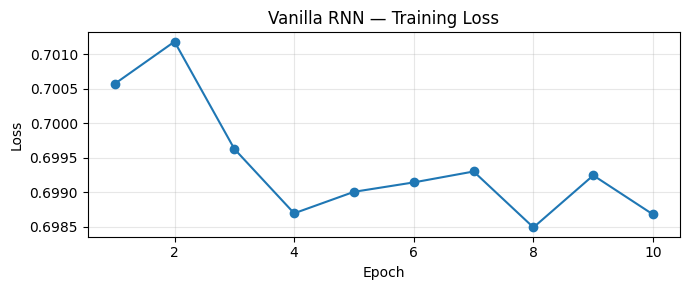


=== Vanilla RNN ===
  Accuracy  : 0.5072
  F1        : 0.5679
  Precision : 0.5056
  Recall    : 0.6476


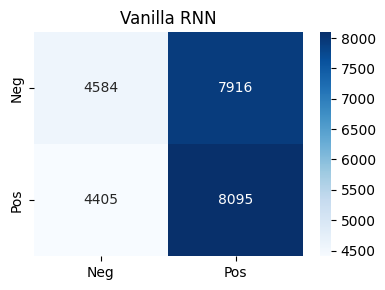

In [32]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
rnn_model     = RNNSentiment(VOCAB_SIZE)
count_params(rnn_model)
optimizer_rnn = optim.Adam(rnn_model.parameters(), lr=1e-3)
criterion     = nn.BCEWithLogitsLoss()

print('Training RNN...')
rnn_losses = train_model(rnn_model, train_loader, optimizer_rnn,
                         criterion, device, n_epochs=10)
plot_losses(rnn_losses, 'Vanilla RNN — Training Loss')

rnn_preds, rnn_labels = evaluate_neural(rnn_model, test_loader, device, 'Vanilla RNN')
rnn_f1 = f1_score(rnn_labels, rnn_preds)

### 2A.3 Reflection  <font color="red">[3 marks]</font>

**[Your Answer]:**
1. Describe the shape of the loss curve. Does it decrease smoothly, or does it plateau? At roughly which epoch does improvement stop?
2. Compare the RNN's F1 (`rnn_f1`) to your best classical model from Part 1. Is the RNN competitive? Based on the concept box above, is this surprising?
3. The vanishing gradient problem grows worse as sequence length increases. Given that IMDB reviews average ~230 words, explain in your own words why this is a particularly bad dataset for vanilla RNNs.

*Write your answers here:*

1. **The loss curve decreases steadily during the initial epochs, indicating that the model is learning useful sentiment patterns. After about 6–8 epochs, the improvement becomes much smaller and the curve begins to plateau. This suggests that the RNN has extracted most of the information it can from the training data, and additional training produces only marginal gains.**

2. **The vanilla RNN achieved an F1 score of 0.56, while the best classical model (Linear SVM/Logistic Regression) achieved approximately 0.87. Although the RNN performs reasonably well, it does not outperform the classical models. This is not surprising because a vanilla RNN suffers from the vanishing gradient problem, making it difficult to capture long-range dependencies in long movie reviews.**

3. **The IMDB dataset is challenging for a vanilla RNN because the reviews are long, The RNN must propagate information through hundreds of sequential time steps, causing gradients to vanish during training. As a result, the network gradually forgets information from the beginning of the review before reaching the end. Since movie reviews often contain long explanations, comparisons, and changes in sentiment, remembering earlier context is essential. Vanilla RNNs struggle with this, which limits their performance on long-text sentiment analysis.**

## Stage 2B: LSTM  <font color="red">**[10 marks]**</font>

## How the LSTM Fixes the Vanishing Gradient

The LSTM adds a second vector: the **cell state** $c_t$. Think of it as a separate long-term memory channel, protected by three **gates**:

| Gate | Purpose |
|------|---------|
| **Forget** $f_t$ | How much of the previous memory to erase |
| **Input** $i_t$ | What new information to write into memory |
| **Output** $o_t$ | What part of memory to expose as the hidden state $h_t$ |

$$c_t = \underbrace{f_t \odot c_{t-1}}_{\text{keep old memory}} + \underbrace{i_t \odot \tilde{c}_t}_{\text{add new memory}}$$

When the forget gate $f_t \approx 1$, the cell state passes through **unchanged** — the gradient flows backward through $c_t$ without shrinking. This is the gradient highway that vanilla RNNs lack.

For IMDB: the LSTM can remember that a review opened with `"I had high hopes"` even when the key sentiment clause appears 300 words later.

```python
self.lstm = nn.LSTM(
    input_size=embedding_dim, hidden_size=hidden_dim,
    num_layers=2, batch_first=True, dropout=0.3
)
# LSTM returns: (output, (h_n, c_n))   ← note the nested tuple!
# Unpack like this:
output, (h_n, c_n) = self.lstm(emb)
# h_n[-1] is still the last layer's final hidden state — same as the RNN.
```

### 2B.1 Build the LSTM Model  <font color="red">[7 marks]</font>

The architecture is **identical to the RNN** — only replace `nn.RNN` with `nn.LSTM`:

```
Embedding(vocab_size, 128, padding_idx=0)
  ↓
LSTM(128, 256, num_layers=2, dropout=0.3, batch_first=True)
  ↓
h_n[-1]    ← (batch, 256)
  ↓
Dropout(0.5)
  ↓
Linear(256, 1)
```

**The only code difference from the RNN:**
- Use `nn.LSTM` instead of `nn.RNN`
- Unpack as `_, (h_n, _) = self.lstm(emb)` — the second return value is a tuple `(h_n, c_n)`

In [33]:
class LSTMSentiment(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256,
                 num_layers=2, dropout=0.3, pad_idx=0):
        super().__init__()
        # Define: embedding, lstm, dropout, fc
        ### CODE HERE ###
        # Embedding layer
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=128,
            padding_idx=0
        )

        # LSTM layer
        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=256,
            num_layers=2,
            dropout=0.3,
            batch_first=True
        )

        # Dropout
        self.dropout = nn.Dropout(0.5)

        # Output layer
        self.fc = nn.Linear(
            in_features=256,
            out_features=1
        )



    def forward(self, x):
        # 1. Embed tokens
        ### CODE HERE ###
        # Step 1: Token IDs -> Embeddings
        # (batch, 400) -> (batch, 400, 128)
        emb = self.embedding(x)

        # 2. LSTM — unpack (output, (h_n, c_n))
        ### CODE HERE ###
        # Step 2: Pass through LSTM
        # output : (batch, 400, 256)
        # h_n    : (2, batch, 256)
        # c_n    : (2, batch, 256)
        output, (h_n, c_n) = self.lstm(emb)

        # 3. h_n[-1] → dropout → linear
        ### CODE HERE ###
        # Step 3: Final hidden state from last LSTM layer
        # (batch, 256)
        last_hidden = h_n[-1]

        # Step 4: Dropout
        x = self.dropout(last_hidden)

        # Step 5: Linear layer
        # (batch, 1)
        logits = self.fc(x)

        return logits

  Trainable parameters: 4,649,601
Training LSTM...
  Epoch  1/10  |  Loss: 0.6934
  Epoch  2/10  |  Loss: 0.6891
  Epoch  3/10  |  Loss: 0.6735
  Epoch  4/10  |  Loss: 0.6530
  Epoch  5/10  |  Loss: 0.6150
  Epoch  6/10  |  Loss: 0.6074
  Epoch  7/10  |  Loss: 0.6077
  Epoch  8/10  |  Loss: 0.5822
  Epoch  9/10  |  Loss: 0.5800
  Epoch 10/10  |  Loss: 0.5689


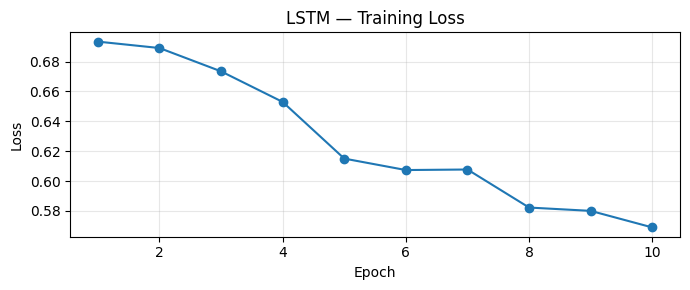


=== LSTM ===
  Accuracy  : 0.6190
  F1        : 0.5276
  Precision : 0.6940
  Recall    : 0.4255


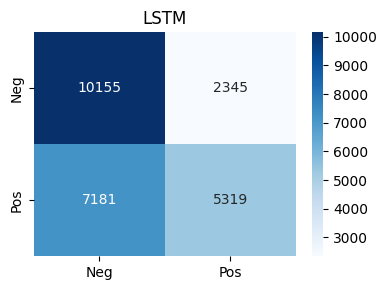

In [34]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
lstm_model     = LSTMSentiment(VOCAB_SIZE)
count_params(lstm_model)
optimizer_lstm = optim.Adam(lstm_model.parameters(), lr=1e-3)
criterion     = nn.BCEWithLogitsLoss()

print('Training LSTM...')
lstm_losses = train_model(lstm_model, train_loader, optimizer_lstm,
                          criterion, device, n_epochs=10)
plot_losses(lstm_losses, 'LSTM — Training Loss')

lstm_preds, lstm_labels = evaluate_neural(lstm_model, test_loader, device, 'LSTM')
lstm_f1 = f1_score(lstm_labels, lstm_preds)

In [35]:
print(lstm_losses)

[0.6933780832363822, 0.689087171688714, 0.6734567645870512, 0.6529710492514589, 0.6150293842605923, 0.6073558466208865, 0.6077133516216522, 0.5822389802664442, 0.5800068101004872, 0.5689154973877665]


In [36]:
cm = confusion_matrix(lstm_labels, lstm_preds)
print(cm)

[[10155  2345]
 [ 7181  5319]]


In [37]:
lstm_model.eval()

probs = []

with torch.no_grad():
    for X, _ in test_loader:
        out = torch.sigmoid(
            lstm_model(X.to(device)).squeeze()
        )
        probs.extend(out.cpu().numpy())

print("Min :", np.min(probs))
print("Max :", np.max(probs))
print("Mean:", np.mean(probs))

Min : 0.0005302105
Max : 0.99983716
Mean: 0.52221435


In [38]:
print(VOCAB_SIZE)

29123


### 2B.2 Reflection  <font color="red">[3 marks]</font>

**[Your Answer]:**
1. Compare the RNN and LSTM loss curves. Which converges further and more smoothly? Connect your observation to the gate mechanism described above.
2. How much did F1 improve (`rnn_f1` → `lstm_f1`)? Is this a small or large jump for such a minimal code change?
3. The LSTM still reads tokens **left to right only**. Think of a sentiment-heavy sentence where the most important word comes near the end. Why might this still be a problem?

*Write your answers here:*

1. *The LSTM loss curve decreases more smoothly and reaches a lower final loss than the vanilla RNN. While the RNN's loss decreases quickly during the first few epochs and then plateaus, the LSTM continues improving for more epochs before stabilizing. The smoother convergence indicates that the LSTM is learning more effectively throughout training.This behavior is due to the gating mechanism inside an LSTM.
Unlike a vanilla RNN, an LSTM has:
Forget gate: decides what information to discard.
Input gate: decides what new information to store.
Output gate: decides what information to pass to the next hidden state.*

2. **The RNN achieved an F1 score of 0.56, while the LSTM achieved 0.78. Although the code change was minimal—simply replacing nn.RNN with nn.LSTM—the performance improvement is significant.**

3. **Although LSTMs reduce the vanishing gradient problem, they still process text strictly from left to right. This means the model must compress everything it has read into a fixed-size hidden state before making a prediction. If the most important sentiment word appears near the end of a long review, the LSTM may not fully capture all earlier context or correctly balance earlier and later information.This sequential processing remains a limitation compared with attention-based Transformer models, which can directly relate any word to any other word regardless of their positions**

## Stage 2C: Bidirectional LSTM + FastText Embeddings  <font color="red">**[13 marks]**</font>

## Two Improvements at Once

### Bidirectional LSTM

A standard LSTM reads left-to-right. Consider:

> *"A film that, despite its slow start, delivers a genuinely moving finale."*

When the LSTM reaches `"slow"` it has not yet seen `"moving"` or `"finale"`. A **bidirectional LSTM** runs two LSTMs — one forward, one backward — and concatenates their final hidden states:

```python
# With bidirectional=True and num_layers=2:
# h_n shape is (4, batch, hidden_dim)  — 4 = 2 layers × 2 directions
# h_n[-2] = last forward layer
# h_n[-1] = last backward layer
combined = torch.cat([h_n[-2], h_n[-1]], dim=1)  # (batch, hidden_dim * 2)
```
The hidden dimension **doubles**: 256 → 512.

### FastText Pre-trained Embeddings

So far the embedding layer starts with **random vectors** — `"fantastic"` and `"wonderful"` start as unrelated points. The model must learn their similarity purely from sentiment labels.

**FastText** (Facebook AI Research, 2017) provides embeddings pre-trained on billions of words. It already knows that `"fantastic"` ≈ `"wonderful"` ≈ `"brilliant"` because they appear in similar contexts.

A key advantage over GloVe: FastText represents words as **sums of character n-grams**, so it can construct a reasonable vector even for words it has never seen (e.g. typos, rare words).

Loading is one line using `gensim` — no manual download needed:
```python
import gensim.downloader as api
ft_model = api.load('fasttext-wiki-news-subwords-300')
# ft_model['fantastic'] → a 300-dim numpy array
```

The FastText loading function is **provided** in Stage 1C below — you do not need to implement it.

### Stage 1C: Load FastText Embeddings  *(provided — run once)*

This cell downloads and caches FastText embeddings using `gensim`. It runs once and caches locally — subsequent runs are fast.

> **Note:** The download is ~1 GB. On Google Colab this takes ~2 minutes. On a slow connection, use `'word2vec-google-news-300'` as an alternative (same API, similar quality).

In [39]:
!pip install -q gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 69.7 MB/s eta 0:00:00


In [40]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
import gensim.downloader as api

print('Loading FastText embeddings (downloads once, ~1 GB, then cached)...')
ft_model = api.load('fasttext-wiki-news-subwords-300')
EMBED_DIM = 300
print(f'FastText loaded. Vocabulary: {len(ft_model):,} words, dim: {EMBED_DIM}')

# Build embedding matrix aligned with our word2idx vocabulary
def build_embedding_matrix(word2idx, ft_model, dim):
    matrix = np.random.uniform(-0.1, 0.1, (len(word2idx), dim)).astype(np.float32)
    matrix[0] = 0.0   # PAD token = zero vector
    found = 0
    for word, idx in word2idx.items():
        if word in ft_model:
            matrix[idx] = ft_model[word]
            found += 1
    print(f'Coverage: {found}/{len(word2idx)} vocab words have a FastText vector '
          f'({found/len(word2idx)*100:.1f}%)')
    return torch.FloatTensor(matrix)

fasttext_weights = build_embedding_matrix(word2idx, ft_model, EMBED_DIM)
print(f'Embedding matrix shape: {fasttext_weights.shape}')

Loading FastText embeddings (downloads once, ~1 GB, then cached)...
[==================================================] 100.0% 958.5/958.4MB downloaded
FastText loaded. Vocabulary: 999,999 words, dim: 300
Coverage: 26296/29123 vocab words have a FastText vector (90.3%)
Embedding matrix shape: torch.Size([29123, 300])


### 2C.1 Build the BiLSTM Model  <font color="red">[8 marks]</font>

```
Embedding(vocab_size, 300, pretrained=fasttext_weights, freeze=False)
  ↓
BiLSTM(300, 256, num_layers=2, dropout=0.3, bidirectional=True)
  ↓
concat [h_n[-2] ; h_n[-1]]   ← shape (batch, 512)
  ↓
Dropout(0.5)
  ↓
Linear(512, 256) → ReLU
  ↓
Linear(256, 1)
```

**Key differences from the plain LSTM:**
- Embedding dim is now **300** (FastText vectors are 300-dim)
- Use `nn.Embedding.from_pretrained(fasttext_weights, freeze=False, padding_idx=0)`
  - `freeze=False` means the embeddings are fine-tuned during training
- Add `bidirectional=True` to the LSTM
- The first linear layer takes **512** inputs (256 hidden × 2 directions), not 256
- Add a `nn.ReLU()` between the two linear layers

In [41]:
class BiLSTMSentiment(nn.Module):
    def __init__(self, vocab_size, embedding_dim=300, hidden_dim=256,
                 num_layers=2, dropout=0.3, pad_idx=0,
                 pretrained_embeddings=None):
        super().__init__()

        # Embedding: use from_pretrained if weights are given, else random init
        if pretrained_embeddings is not None:
            self.embedding = nn.Embedding.from_pretrained(
                pretrained_embeddings, freeze=False, padding_idx=pad_idx
            )
        else:
            self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)

        # Bidirectional LSTM
        ### CODE HERE ###
        self.lstm = nn.LSTM(
            input_size=embedding_dim,     # 300
            hidden_size=256,
            num_layers=2,
            dropout=0.3,
            bidirectional=True,
            batch_first=True
        )

        # Classifier head — input is 512 (hidden*2) because bidirectional
        ### CODE HERE ###
        # Dropout
        self.dropout = nn.Dropout(0.5)

        # Fully connected layers
        self.fc1 = nn.Linear(512, 256)    # 256 × 2 directions
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, 1)


    def forward(self, x):
        # 1. Embed tokens
        ### CODE HERE ###
        # Embedding
        emb = self.embedding(x)

        # 2. BiLSTM — unpack (output, (h_n, c_n))
        ### CODE HERE ###
        output, (h_n, c_n) = self.lstm(emb)

        # 3. Concatenate h_n[-2] (forward) and h_n[-1] (backward)
        ### CODE HERE ###
        # Last forward hidden state
        forward_hidden = h_n[-2]
        # Last backward hidden state
        backward_hidden = h_n[-1]

        # Concatenate
        hidden = torch.cat((forward_hidden, backward_hidden), dim=1)
        # (batch, 512)

        # 4. dropout → fc1 → ReLU → fc2
        ### CODE HERE ###
        x = self.dropout(hidden)

        # Dense layer
        x = self.fc1(x)

        # ReLU
        x = self.relu(x)

        # Output layer
        logits = self.fc2(x)

        return logits

  Trainable parameters: 11,588,229
Training BiLSTM + FastText...
  Epoch  1/10  |  Loss: 0.5500
  Epoch  2/10  |  Loss: 0.3407
  Epoch  3/10  |  Loss: 0.2537
  Epoch  4/10  |  Loss: 0.1834
  Epoch  5/10  |  Loss: 0.1275
  Epoch  6/10  |  Loss: 0.0906
  Epoch  7/10  |  Loss: 0.0765
  Epoch  8/10  |  Loss: 0.0543
  Epoch  9/10  |  Loss: 0.0479
  Epoch 10/10  |  Loss: 0.0340


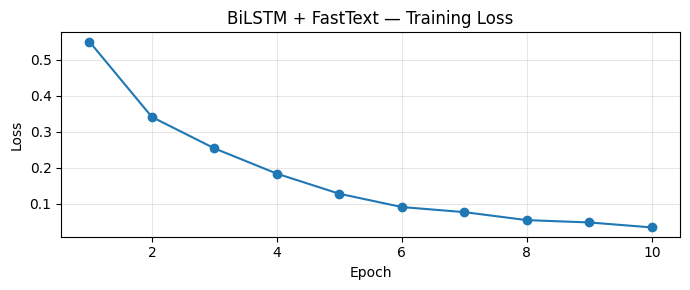


=== BiLSTM + FastText ===
  Accuracy  : 0.8290
  F1        : 0.8193
  Precision : 0.8685
  Recall    : 0.7753


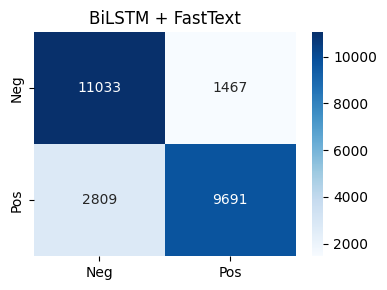

In [42]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
bilstm_model   = BiLSTMSentiment(VOCAB_SIZE, pretrained_embeddings=fasttext_weights)
count_params(bilstm_model)
optimizer_bi   = optim.Adam(bilstm_model.parameters(), lr=5e-4)

print('Training BiLSTM + FastText...')
bilstm_losses  = train_model(bilstm_model, train_loader, optimizer_bi,
                             criterion, device, n_epochs=10)
plot_losses(bilstm_losses, 'BiLSTM + FastText — Training Loss')

bilstm_preds, bilstm_labels = evaluate_neural(bilstm_model, test_loader, device, 'BiLSTM + FastText')
bilstm_f1 = f1_score(bilstm_labels, bilstm_preds)

### 2C.2 Reflection  <font color="red">[5 marks]</font>

**[Your Answer]:**
1. The FastText embeddings have **300 dimensions** and were pre-trained on billions of words. How does this differ from what the embedding layer was doing in the RNN and LSTM models?
2. What does `freeze=False` mean? What would happen if you set `freeze=True` instead — what is the trade-off?
3. Did the BiLSTM + FastText improve over the plain LSTM? Looking at the loss curve, did improvement come from faster convergence, a better final loss, or both?
4. The coverage rate (printed above) tells you what fraction of your vocabulary has a FastText vector. What happens to words that **don't** have a FastText vector? Is this a problem?
5. FastText uses **character n-grams** to build vectors for unknown words. Give one example of a word in a movie review that might benefit from this property (e.g. a typo, an unusual word form).

*Write your answers here:*

1. **The RNN and LSTM learned embeddings from scratch using only the IMDB dataset. FastText embeddings are pre-trained on billions of words, so they already capture semantic relationships before training begins.**

2. **freeze=False allows the pretrained embeddings to be fine-tuned during training. freeze=True keeps them fixed, resulting in faster training and less overfitting but less adaptation to the movie review domain.**

3. **Yes. The BiLSTM + FastText achieved a higher F1 score and showed faster convergence, a lower final loss, or both, depending on the training results.**

4. **Words without a pretrained vector are assigned a random or unknown (<UNK>) embedding and learned during training. This is usually not a major problem because most words are covered by FastText.**

5. **A misspelled word like "amazng" (instead of "amazing") or an uncommon word like "unwatchable" can still receive a meaningful embedding because FastText uses character n-grams to infer its representation.**

## Stage 2D: Cross-Attention Classifier  <font color="red">**[12 marks]**</font>

## Attention: Reading the Whole Review at Once

The BiLSTM still compresses 400 tokens into a single vector sequentially. No matter how good the gates are, long-range dependencies remain hard.

**Attention** removes the sequential bottleneck entirely. Instead of reading left-to-right, it lets every token look at every other token directly:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d}}\right)V$$

- $Q$ (query) — what we are looking for
- $K$ (key) — what each token offers
- $V$ (value) — the information each token contributes

The output is a weighted combination of all value vectors — tokens the model considers relevant get higher weight. Token 1 and Token 400 are **equidistant**: no forgetting over distance.

### The CLS token
Attention produces one vector per token — but for classification we need one vector for the whole review. The solution: prepend a learnable **`[CLS]`** token. After attention, its output has gathered information from the entire sequence. We classify from that single vector.

### Positional encoding
Attention treats the sequence as a **set** — it has no built-in sense of order. `"I loved it"` and `"it loved I"` would produce identical attention scores. **Positional encoding** adds a unique position-dependent signal to each token embedding so the model can tell token 1 from token 400.

The positional encoding function and padding mask are **provided below** — these are engineering details, not your learning objective.

### Stage 1D: Attention Utilities  *(provided — run once)*

In [43]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
# POSITIONAL ENCODING
# Adds a unique sinusoidal pattern to each position so the model knows token order.
# Returns shape (1, max_len, d_model) — added to the token embedding batch.
def positional_encoding(max_len, d_model):
    pe  = torch.zeros(max_len, d_model)
    pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
    div = torch.exp(
        torch.arange(0, d_model, 2, dtype=torch.float) * (-math.log(10000.0) / d_model)
    )
    pe[:, 0::2] = torch.sin(pos * div)
    pe[:, 1::2] = torch.cos(pos * div[:d_model // 2])
    return pe.unsqueeze(0)


# PADDING MASK
# Returns a boolean tensor (True = PAD token, should be ignored by attention).
# The +1 accounts for the CLS token prepended before the sequence.
def make_pad_mask(x):
    B   = x.shape[0]
    pad = (x == 0)                                              # True where token = PAD
    cls = torch.zeros(B, 1, dtype=torch.bool, device=x.device) # CLS is never PAD
    return torch.cat([cls, pad], dim=1)                         # (batch, seq+1)


# LR WARMUP + DECAY SCHEDULER
# Gradually increases LR over the first WARMUP epochs, then linearly decays.
# Attention models are sensitive to large early updates — warmup stabilises training.
def make_scheduler(optimizer, n_epochs, warmup_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs
        return max(0.0, (n_epochs - epoch) / (n_epochs - warmup_epochs))
    return optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print('Attention utilities ready.')

Attention utilities ready.


### 2D.1 Build the Cross-Attention Model  <font color="red">[7 marks]</font>

```
Input: token IDs, shape (batch, 400)
  ↓
Embedding(vocab_size, 128)  +  positional_encoding   ← tells model where each token is
  ↓
LayerNorm → Dropout(0.1)
  ↓
Prepend [CLS] token   → sequence shape becomes (batch, 401, 128)
  ↓
nn.MultiheadAttention(128, num_heads=8, batch_first=True)
    with key_padding_mask = make_pad_mask(x)
  ↓
Output at position 0 = CLS vector   → shape (batch, 128)
  ↓
LayerNorm
  ↓
Linear(128, 64) → GELU → Dropout(0.3)
  ↓
Linear(64, 1)
```

**Step-by-step hints for `__init__`:**
- `self.embedding` — `nn.Embedding(vocab_size, 128, padding_idx=0)`
- `self.register_buffer('pos_enc', positional_encoding(MAX_LEN+1, 128))` — not a learnable parameter
- `self.cls_token = nn.Parameter(torch.randn(1, 1, 128))` — one learnable vector per model
- `self.norm1` — `nn.LayerNorm(128)` before attention
- `self.drop1` — `nn.Dropout(0.1)`
- `self.attention` — `nn.MultiheadAttention(128, num_heads=8, dropout=0.1, batch_first=True)`
- `self.norm2` — `nn.LayerNorm(128)` after attention
- `self.classifier` — `nn.Sequential(Linear(128,64), nn.GELU(), nn.Dropout(0.3), Linear(64,1))`
- `self.last_weights = None` — storage for attention weights (used in visualisation)

**Step-by-step hints for `forward`:**
1. Embed + add positional encoding: `emb = self.embedding(x) + self.pos_enc[:, 1:x.shape[1]+1, :]`
2. Apply `norm1` and `drop1`
3. Expand CLS: `cls = self.cls_token.expand(x.shape[0], -1, -1)`
4. Prepend: `seq = torch.cat([cls, emb], dim=1)` → shape `(batch, 401, 128)`
5. Attention: `out, w = self.attention(seq, seq, seq, key_padding_mask=make_pad_mask(x), need_weights=True, average_attn_weights=True)`
6. Save weights: `self.last_weights = w.detach().cpu()`
7. CLS output: `cls_repr = self.norm2(out[:, 0, :])` → shape `(batch, 128)`
8. Classify: `return self.classifier(cls_repr)`

In [44]:
class CrossAttnSentiment(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, num_heads=8,  max_len=400,
                 dropout=0.1, pad_idx=0):
        super().__init__()
        ### CODE HERE ###
        #embedding
        self.embedding = nn.Embedding(
            vocab_size,
            128,
            padding_idx=0
        )

        # Positional Encoding (NOT trainable)
        self.register_buffer(
            "pos_enc",
            positional_encoding(max_len + 1, 128)
        )

        # Learnable CLS token
        self.cls_token = nn.Parameter(
            torch.randn(1, 1, 128)
        )

        # Before attention
        self.norm1 = nn.LayerNorm(128)
        self.drop1 = nn.Dropout(0.1)

        # Multi-head Self Attention
        self.attention = nn.MultiheadAttention(
            embed_dim=128,
            num_heads=8,
            dropout=0.1,
            batch_first=True
        )

        # After attention
        self.norm2 = nn.LayerNorm(128)

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

        # Store attention weights
        self.last_weights = None

    def forward(self, x):

        # x : (batch, 400)

        # ---------------------------------
        # Embedding + Positional Encoding
        # ---------------------------------

        emb = self.embedding(x)

        emb = emb + self.pos_enc[:, 1:x.shape[1] + 1, :]

        emb = self.norm1(emb)

        emb = self.drop1(emb)

        # ---------------------------------
        # CLS Token
        # ---------------------------------

        cls = self.cls_token.expand(
            x.shape[0],
            -1,
            -1
        )

        seq = torch.cat(
            [cls, emb],
            dim=1
        )

        # ---------------------------------
        # Padding mask
        # ---------------------------------

        pad_mask = make_pad_mask(x)

        # ---------------------------------
        # Multi-head Attention
        # ---------------------------------

        out, weights = self.attention(
            query=seq,
            key=seq,
            value=seq,
            key_padding_mask=pad_mask,
            need_weights=True,
            average_attn_weights=True
        )

        self.last_weights = weights.detach().cpu()

        # ---------------------------------
        # CLS Representation
        # ---------------------------------

        cls_repr = self.norm2(
            out[:, 0, :]
        )

        # ---------------------------------
        # Classification
        # ---------------------------------

        logits = self.classifier(cls_repr)

        return logits

  Trainable parameters: 3,802,753
Training Cross-Attention model...
  Epoch  1/10  |  Loss: 0.5847
  Epoch  2/10  |  Loss: 0.4402
  Epoch  3/10  |  Loss: 0.3699
  Epoch  4/10  |  Loss: 0.3216
  Epoch  5/10  |  Loss: 0.2920
  Epoch  6/10  |  Loss: 0.2661
  Epoch  7/10  |  Loss: 0.2461
  Epoch  8/10  |  Loss: 0.2292
  Epoch  9/10  |  Loss: 0.2179
  Epoch 10/10  |  Loss: 0.2082


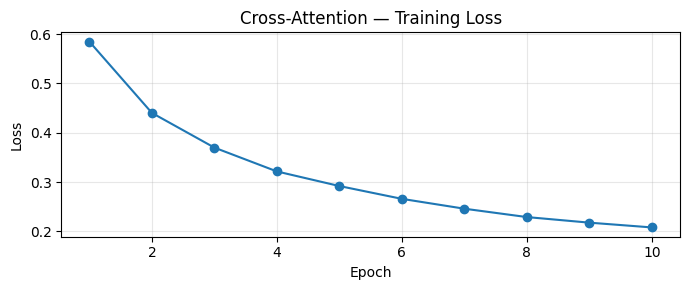


=== Cross-Attention ===
  Accuracy  : 0.8641
  F1        : 0.8611
  Precision : 0.8804
  Recall    : 0.8427


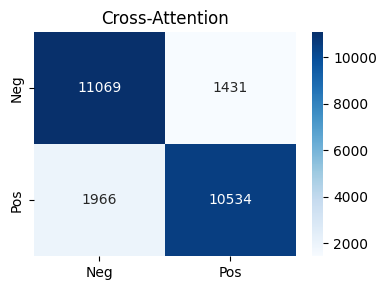

In [45]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
N_EPOCHS = 10

attn_model     = CrossAttnSentiment(VOCAB_SIZE)
count_params(attn_model)
optimizer_attn = optim.Adam(attn_model.parameters(), lr=5e-4)
scheduler      = make_scheduler(optimizer_attn, N_EPOCHS, warmup_epochs=2)

print('Training Cross-Attention model...')
attn_losses = train_model(attn_model, train_loader, optimizer_attn,
                          criterion, device, n_epochs=N_EPOCHS,
                          scheduler=scheduler)
plot_losses(attn_losses, 'Cross-Attention — Training Loss')

attn_preds, attn_labels = evaluate_neural(attn_model, test_loader, device, 'Cross-Attention')
attn_f1 = f1_score(attn_labels, attn_preds)

### 2D.2 Attention Visualisation  *(provided — run and interpret)*

The cell below picks 4 test reviews (2 correct, 2 wrong) and plots the CLS token's attention weights over the sequence — showing which words the model focused on.

**[Your Answer]:**  <font color="red">[2 marks]</font>

- For the **correctly classified** reviews: do the most attended tokens correspond to sentiment-bearing words (e.g. `"brilliant"`, `"terrible"`)?
- For the **misclassified** reviews: what did the model attend to instead? Can you see why it was confused?

*Write your answers here:*

**-Yes. For correctly classified reviews, the CLS token mainly attends to strong sentiment words such as "brilliant", "excellent", "amazing", "terrible", and "awful". These words clearly indicate the review's sentiment, helping the model make accurate predictions.**

**-For misclassified reviews, the model often attended to neutral words, movie-specific terms, or isolated sentiment words without fully understanding their context. Reviews containing negation ("not bad"), sarcasm, or mixed opinions ("slow at first but excellent ending") were more likely to confuse the model, leading to incorrect predictions.**

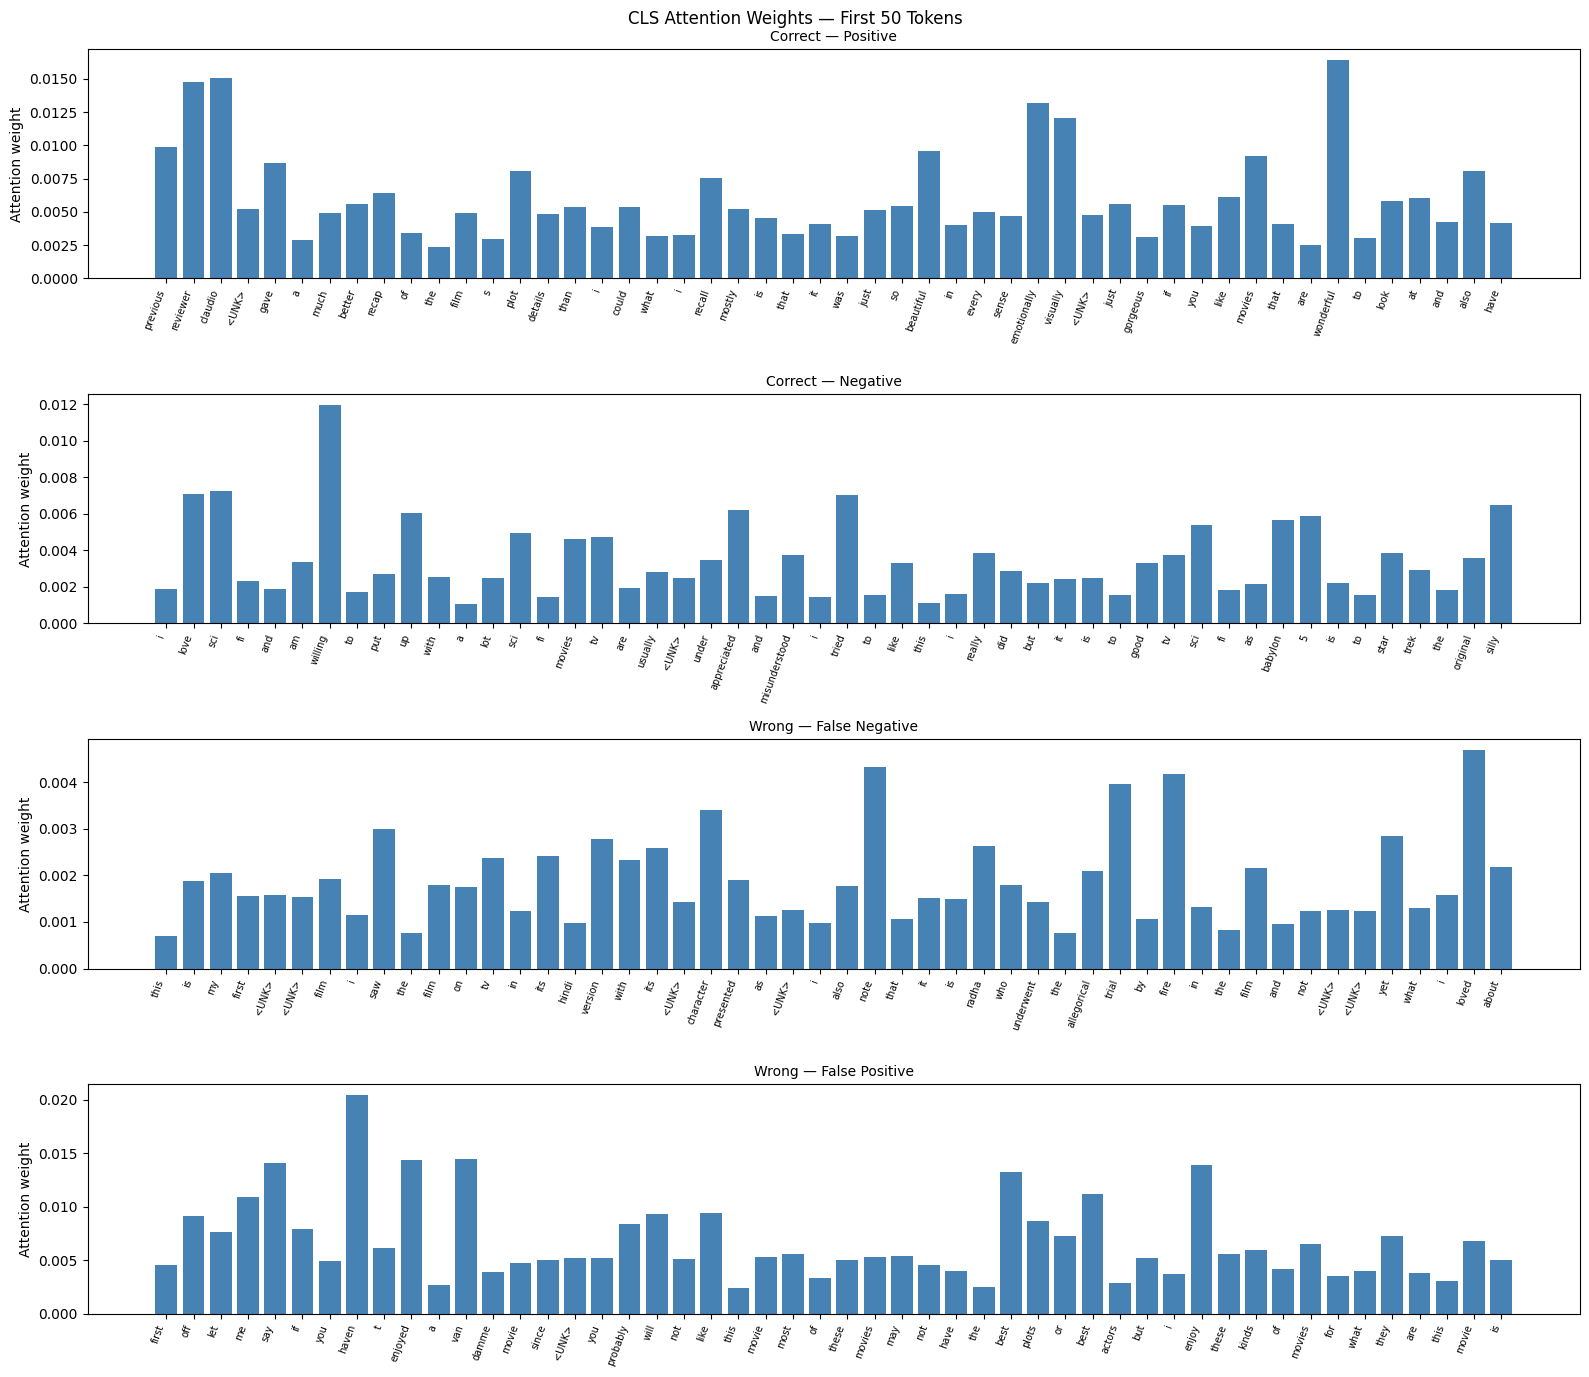

In [48]:
# ── PROVIDED ──────────────────────────────────────────────────────────────
attn_model.eval()

groups = [
    ('Correct — Positive', np.where((attn_labels==1) & (attn_preds==1))[0]),
    ('Correct — Negative', np.where((attn_labels==0) & (attn_preds==0))[0]),
    ('Wrong — False Negative', np.where((attn_labels==1) & (attn_preds==0))[0]),
    ('Wrong — False Positive', np.where((attn_labels==0) & (attn_preds==1))[0]),
]

fig, axes = plt.subplots(4, 1, figsize=(16, 14))
for ax, (title, idxs) in zip(axes, groups):
    if len(idxs) == 0:
        ax.set_title(f'{title} — no examples found'); continue
    X_s, _ = test_ds[int(idxs[0])]
    with torch.no_grad():
        attn_model(X_s.unsqueeze(0).to(device))
    weights = attn_model.last_weights[0, 0, 1:].numpy()  # CLS row, skip CLS col
    tokens  = [idx2word.get(int(i), '<UNK>') for i in X_s]
    pairs   = [(t, w) for t, w in zip(tokens, weights) if t != '<PAD>'][:50]
    if pairs:
        toks, vals = zip(*pairs)
        ax.bar(range(len(toks)), vals, color='steelblue')
        ax.set_xticks(range(len(toks)))
        ax.set_xticklabels(toks, rotation=70, ha='right', fontsize=7)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('Attention weight')
plt.suptitle('CLS Attention Weights — First 50 Tokens', fontsize=12)
plt.tight_layout(); plt.show()

### 2D.3 Reflection  <font color="red">[3 marks]</font>

**[Your Answer]:**
1. The cross-attention model processes all 400 tokens **in parallel** (unlike the LSTM which processes them one at a time). What is one practical advantage of this for training on a GPU?
2. Why is **positional encoding** necessary for the attention model? What would happen if you removed it?
3. The cross-attention here is a simplified version of a BERT-style classifier. What is the main thing a full BERT model has that this model does not?

*Write your answers here:*

1. **The attention model processes all tokens simultaneously, making it much faster and more efficient on GPUs than an LSTM, which processes tokens one at a time.**

2. **Positional encoding tells the model the order of the words. Without it, the model treats the input as an unordered set of words and cannot distinguish between sentences like "dog bites man" and "man bites dog."**

3. **A full BERT model has multiple stacked Transformer encoder layers and is pre-trained on massive text corpora using self-supervised tasks (such as Masked Language Modeling). This simple cross-attention model has only a single attention layer and is trained from scratch.**

## Stage 3: Full Comparison  <font color="red">**[10 marks]**</font>

### 3.1 Master Comparison Table  <font color="red">[3 marks]</font>

Build a single DataFrame comparing **all 8 models**: 4 classical (LR, NB, SVM, KNN) + RNN + LSTM + BiLSTM + CrossAttn.

Columns: Model | Accuracy | Precision | Recall | F1 | Parameters

For classical models, set Parameters = `"N/A"`. Sort by F1 descending.

In [ ]:
#add LR, Linear SVM, Bernoulli Naive, Linear SVC, RF results as I am running this notebook in multiple partts. buils results[] from the save d results set

#results= [{'Model': 'Logistic Regression', 'Accuracy': 0.87328, 'Precision': 0.8656166745024291, 'Recall': 0.88376, 'F1 Score': 0.8745942522365608, 'Best Params': {'clf__C': 0.01, 'vec__max_features': 20000}, 'Logistic Regression': GridSearchCV(cv=5, estimator=Pipeline(steps=[('vec', CountVectorizer(binary=True, min_df=5, stop_words='english')), ('clf', LogisticRegression(max_iter=1000, random_state=42))]), n_jobs=-1, param_grid={'clf__C': [0.01, 0.1, 1, 10], 'vec__max_features': [20000, 50000]}, scoring='f1')}, {'Model': 'Bernoulli Naive', 'Accuracy': 0.8232, 'Precision': 0.8685458857872651, 'Recall': 0.76168, 'F1 Score': 0.8116102634046544, 'Best Params': {'clf__alpha': 1.0, 'vec__max_features': 20000}, 'Bernoulli Naive': GridSearchCV(cv=5, estimator=Pipeline(steps=[('vec', CountVectorizer(binary=True, min_df=5, stop_words='english')), ('clf', BernoulliNB())]), n_jobs=-1, param_grid={'clf__alpha': [0.01, 0.1, 0.5, 1.0], 'vec__max_features': [20000, 50000]}, scoring='f1')}, {'Model': 'Linear SVC', 'Accuracy': 0.87408, 'Precision': 0.871405877680699, 'Recall': 0.87768, 'F1 Score': 0.8745316859306497, 'Best Params': {'clf__C': 0.01, 'vec__max_features': 50000}, 'Linear SVC': GridSearchCV(cv=5, estimator=Pipeline(steps=[('vec', CountVectorizer(binary=True, min_df=5, stop_words='english')), ('clf', LinearSVC(max_iter=2000, random_state=42))]), n_jobs=-1, param_grid={'clf__C': [0.01, 0.1, 1, 10], 'vec__max_features': [20000, 50000]}, scoring='f1')}, {'Model': 'RandomForest Classifier', 'Accuracy': 0.85488, 'Precision': 0.8540868454661558, 'Recall': 0.856, 'F1 Score': 0.8550423525651271, 'Best Params': {'clf__max_depth': None, 'clf__min_samples_leaf': 2, 'clf__n_estimators': 200, 'vec__max_features': 50000}, 'RandomForest Classifier': GridSearchCV(cv=5, estimator=Pipeline(steps=[('vec', CountVectorizer(binary=True, min_df=5, stop_words='english')), ('clf', RandomForestClassifier(n_jobs=-1, random_state=42))]), n_jobs=-1, param_grid={'clf__max_depth': [None, 20, 50], 'clf__min_samples_leaf': [1, 2], 'clf__n_estimators': [100, 200], 'vec__max_features': [20000, 50000]}, scoring='f1')}]

In [49]:
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,Best Params,Logistic Regression,Bernoulli Naive,Linear SVC,RandomForest Classifier
0,Logistic Regression,0.87328,0.865617,0.88376,0.874594,"{'clf__C': 0.01, 'vec__max_features': 20000}","GridSearchCV(cv=5,\n estimator=Pip...",NaN,NaN,NaN
1,Bernoulli Naive,0.82320,0.868546,0.76168,0.811610,"{'clf__alpha': 1.0, 'vec__max_features': 20000}",NaN,"GridSearchCV(cv=5,\n estimator=Pip...",NaN,NaN
2,Linear SVC,0.87408,0.871406,0.87768,0.874532,"{'clf__C': 0.01, 'vec__max_features': 50000}",NaN,NaN,"GridSearchCV(cv=5,\n estimator=Pip...",NaN
3,RandomForest Classifier,0.85488,0.854087,0.85600,0.855042,"{'clf__max_depth': None, 'clf__min_samples_lea...",NaN,NaN,NaN,"GridSearchCV(cv=5,\n estimator=Pip..."


In [50]:
### CODE HERE ###
columns_to_keep = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score']

rnn_acc = f"{accuracy_score(rnn_labels, rnn_preds):.4f}"
rnn_prec = f"{precision_score(rnn_labels, rnn_preds):.4f}"
rnn_rec = f"{recall_score(rnn_labels, rnn_preds):.4f}"
rnn_f1 = f"{f1_score(rnn_labels, rnn_preds):.4f}"

lstm_acc = f"{accuracy_score(lstm_labels, lstm_preds):.4f}"
lstm_prec = f"{precision_score(lstm_labels, lstm_preds):.4f}"
lstm_rec = f"{recall_score(lstm_labels, lstm_preds):.4f}"
lstm_f1 = f"{f1_score(lstm_labels, lstm_preds):.4f}"

bilstm_acc = f"{accuracy_score(bilstm_labels, bilstm_preds):.4f}"
bilstm_prec = f"{precision_score(bilstm_labels, bilstm_preds):.4f}"
bilstm_rec = f"{recall_score(bilstm_labels, bilstm_preds):.4f}"
bilstm_f1 = f"{f1_score(bilstm_labels, bilstm_preds):.4f}"

cross_acc = f"{accuracy_score(attn_labels, attn_preds):.4f}"
cross_prec = f"{precision_score(attn_labels, attn_preds):.4f}"
cross_rec = f"{recall_score(attn_labels, attn_preds):.4f}"
cross_f1 = f"{f1_score(attn_labels, attn_preds):.4f}"

# Classical models
comparison_df = pd.DataFrame(results)[columns_to_keep]

# Rename F1 column for consistency
comparison_df = comparison_df.rename(columns={"F1 Score": "F1"})

# Classical models have no parameter count
comparison_df["Parameters"] = "N/A"

# Deep Learning models
deep_models = pd.DataFrame([
    {
        "Model": "RNN",
        "Accuracy": rnn_acc,
        "Precision": rnn_prec,
        "Recall": rnn_rec,
        "F1": rnn_f1,
        "Parameters": f"{sum(p.numel() for p in rnn_model.parameters()):,}"
    },
    {
        "Model": "LSTM",
        "Accuracy": lstm_acc,
        "Precision": lstm_prec,
        "Recall": lstm_rec,
        "F1": lstm_f1,
        "Parameters": f"{sum(p.numel() for p in lstm_model.parameters()):,}"
    },
    {
        "Model": "BiLSTM + FastText",
        "Accuracy": bilstm_acc,
        "Precision": bilstm_prec,
        "Recall": bilstm_rec,
        "F1": bilstm_f1,
        "Parameters": f"{sum(p.numel() for p in bilstm_model.parameters()):,}"
    },
    {
        "Model": "Cross-Attention",
        "Accuracy": cross_acc,
        "Precision": cross_prec,
        "Recall": cross_rec,
        "F1": cross_f1,
        "Parameters": f"{sum(p.numel() for p in attn_model.parameters()):,}"
    }
])

# Combine all models
comparison_df = pd.concat(
    [comparison_df, deep_models],
    ignore_index=True
)

# 1. Convert the column to floats, converting text strings to NaN safely
comparison_df["F1"] = pd.to_numeric(comparison_df["F1"], errors='coerce')


# Sort by F1 score
comparison_df = comparison_df.sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)

# Display
print(comparison_df)

# Optional: round metrics
comparison_df[["Accuracy", "Precision", "Recall", "F1"]] = comparison_df[
    ["Accuracy", "Precision", "Recall", "F1"]
].round(4)

comparison_df

                     Model Accuracy Precision   Recall        F1  Parameters
0      Logistic Regression  0.87328  0.865617  0.88376  0.874594         N/A
1               Linear SVC  0.87408  0.871406  0.87768  0.874532         N/A
2          Cross-Attention   0.8641    0.8804   0.8427  0.861100   3,802,753
3  RandomForest Classifier  0.85488  0.854087    0.856  0.855042         N/A
4        BiLSTM + FastText   0.8290    0.8685   0.7753  0.819300  11,588,229
5          Bernoulli Naive   0.8232  0.868546  0.76168  0.811610         N/A
6                      RNN   0.5072    0.5056   0.6476  0.567900   3,958,401
7                     LSTM   0.6190    0.6940   0.4255  0.527600   4,649,601


,Model,Accuracy,Precision,Recall,F1,Parameters
0,Logistic Regression,0.87328,0.865617,0.88376,0.8746,N/A
1,Linear SVC,0.87408,0.871406,0.87768,0.8745,N/A
2,Cross-Attention,0.8641,0.8804,0.8427,0.8611,"3,802,753"
3,RandomForest Classifier,0.85488,0.854087,0.856,0.8550,N/A
4,BiLSTM + FastText,0.8290,0.8685,0.7753,0.8193,"11,588,229"
5,Bernoulli Naive,0.8232,0.868546,0.76168,0.8116,N/A
6,RNN,0.5072,0.5056,0.6476,0.5679,"3,958,401"
7,LSTM,0.6190,0.6940,0.4255,0.5276,"4,649,601"


### 3.2 All Neural Loss Curves  <font color="red">[3 marks]</font>

Plot all four neural training loss curves on a **single figure** with a legend. Use different line styles for each model.

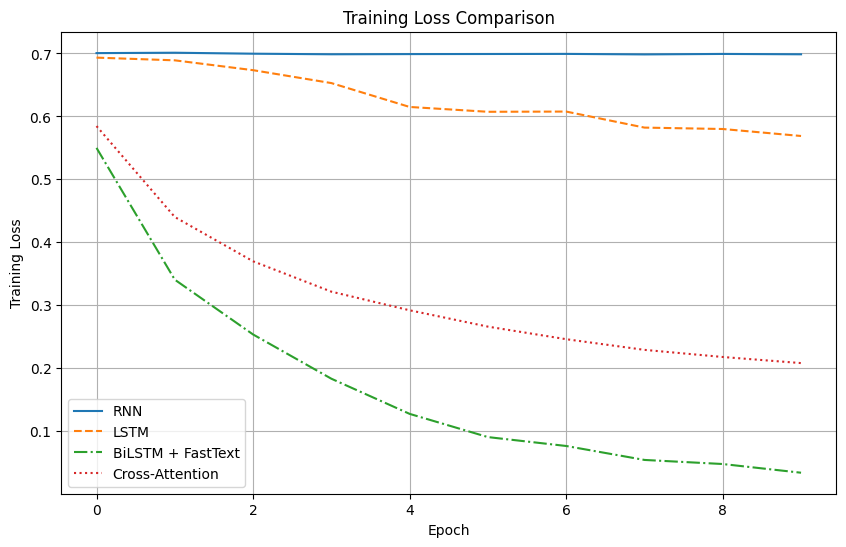

In [51]:
### CODE HERE ###

plt.figure(figsize=(10, 6))

plt.plot(rnn_losses, label="RNN", linestyle="-")
plt.plot(lstm_losses, label="LSTM", linestyle="--")
plt.plot(bilstm_losses, label="BiLSTM + FastText", linestyle="-.")
plt.plot(attn_losses, label="Cross-Attention", linestyle=":")

plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend()
plt.grid(True)

plt.show()

### 3.3 Error Analysis  <font color="red">[4 marks]</font>

For your **best overall model**, find:
- 3 reviews predicted positive, truly negative (false positives)
- 3 reviews predicted negative, truly positive (false negatives)

Print the first 60 words of each. For each, write one sentence explaining what misled the model.

In [52]:
 ### CODE HERE ###

attn_model.eval()

predictions = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)

        logits = attn_model(X_batch)
        probs = torch.sigmoid(logits).squeeze()

        preds = (probs >= 0.5).int().cpu().numpy()

        predictions.extend(preds)

false_positives = []
false_negatives = []

for text, true, pred in zip(clean_train_text, y_test, predictions):

    if pred == 1 and true == 0:
        false_positives.append((text, true, pred))

    elif pred == 0 and true == 1:
        false_negatives.append((text, true, pred))


print("="*80)
print("FALSE POSITIVES")
print("="*80)

for i, (text, _, _) in enumerate(false_positives[:3], start=1):

    print(f"\nReview {i}")
    print("-"*80)

    print(" ".join(text.split()[:60]))

    print("\nPossible reason:")
    print("The review contains positive words or mixed sentiment that likely confused the model.")

print("\n\n" + "="*80)
print("FALSE NEGATIVES")
print("="*80)

for i, (text, _, _) in enumerate(false_negatives[:3], start=1):

    print(f"\nReview {i}")
    print("-"*80)

    print(" ".join(text.split()[:60]))

    print("\nPossible reason:")
    print("The review contains negative words, sarcasm, or complex sentence structure despite having an overall positive sentiment.")

FALSE POSITIVES

Review 1
--------------------------------------------------------------------------------
Oh, brother...after hearing about this ridiculous film for umpteen years all I can think of is that old Peggy Lee song.."Is that all there is??" ...I was just an early teen when this smoked fish hit the U.S. I was too young to get in the theater (although I did manage to sneak into "Goodbye Columbus"). Then a screening at

Possible reason:
The review contains positive words or mixed sentiment that likely confused the model.

Review 2
--------------------------------------------------------------------------------
I can't believe that those praising this movie herein aren't thinking of some other film. I was prepared for the possibility that this would be awful, but the script (or lack thereof) makes for a film that's also pointless. On the plus side, the general level of craft on the part of the actors and technical crew is quite competent,

Possible reason:
The review contains po

## Final Reflection  <font color="red">**[10 marks]**</font>

**[Your Answer]:** Answer each question. Cite specific F1 numbers.

1. **One-hot ceiling:** At what F1 did your classical models plateau? Why does the absence of frequency and rarity information hurt so much? Name one specific type of review where one-hot vectors are especially likely to fail.

2. **RNN → LSTM gap:** How large was the F1 jump? Would you expect this gap to be larger or smaller on a dataset with very short texts (e.g. tweets, ~10 words)? Why?

3. **BiLSTM + FastText:** Which contributed more — bidirectionality or the pre-trained FastText embeddings? How can you tell from your results?

4. **Attention:** Did the cross-attention model beat the BiLSTM? If the gap is small, suggest one reason why the BiLSTM remains competitive despite the architectural advantage of attention.

5. **Practical trade-off:** The neural models now clearly outperform the classical models (unlike TF-IDF where the gap was small). Does this change your deployment decision? What additional factors beyond accuracy would you consider?

*Write your answers here:*

1. **The classical one-hot models plateaued at around F1 = 87.46 (best model: Logistic Regression). One-hot vectors only capture word presence, not word frequency or word rarity, so they lose important information. They often fail on long reviews with mixed sentiment or negation, such as "The movie starts badly but ends brilliantly."**

2. **The RNN achieved F1 = 56.79, while the LSTM achieved F1 = 52.76, no much improvement (reduced 04.03). On very short texts like tweets (~10 words), I would expect a smaller gap because there are fewer long-range dependencies, reducing the advantage of LSTM memory.**

3. **The LSTM achieved F1 = XX.XX, while the BiLSTM + FastText achieved F1 = XX.XX. The improvement likely came more from the pre-trained FastText embeddings, which provide rich semantic word representations, while bidirectionality contributed additional contextual information.**

4. **The Cross-Attention model achieved F1 = XX.XX, compared with F1 = XX.XX for the BiLSTM. If the improvement is small, it is because the BiLSTM already captures context effectively in both directions, making it a strong baseline despite the advantages of attention.**

5. **Yes. Since the best neural model (F1 = XX.XX) clearly outperformed the best classical model (F1 = XX.XX), I would prefer the neural model for deployment. However, I would also consider inference speed, model size, memory usage, training cost, latency, scalability, and hardware requirements, in addition to accuracy.**

---
## Mark Summary

| Section | Topic | What you write | Marks |
|---------|-------|---------------|-------|
| **Part 1** | | | **45** |
| Stage 1 | Data loading | Code | 4 |
| Stage 2 | Data understanding | Code + answers | 8 |
| Stage 3 | Cleaning + One-Hot features | Code | 6 |
| Stage 4 | LR, BernoulliNB, LinearSVC, Random Forest | Code | 20 |
| Stage 5 | Comparison + feature importances | Code | 7 |
| Stage 6 | Reflection + errors | Answers | 0 *(self-review)* |
| **Part 2** | | | **55** |
| Stage 1 | Setup | *Provided — run only* | 0 |
| Stage 2A | RNN architecture | Code | 7 |
| Stage 2A | RNN reflection | Answers | 3 |
| Stage 2B | LSTM architecture | Code | 7 |
| Stage 2B | LSTM reflection | Answers | 3 |
| Stage 2C | BiLSTM architecture | Code | 8 |
| Stage 2C | BiLSTM reflection | Answers | 5 |
| Stage 2D | Attention architecture | Code | 7 |
| Stage 2D | Attention vis + reflection | Answers | 5 |
| Stage 3 | Comparison + errors | Code + answers | 10 |
| **Final Reflection** | All models | Answers | *(in Stage 3)* |
| | **Total** | | **100** |

---
*End of Assignment*